## Reproducibility Study Dataset Generation

This jupyter notebook provides a way to generate the datasets used in the reproducibility studies.
The notebook provides a step-by-step filtering to generate the datasets for modelset dataset to be used for the reproducibility study.
Given that the library was developed after the dataset was generated, to provide evidence for reusability of the library, the jupyter notebook provides model filtering code snippets that show how using the library gives the same results as the 'without-library-code' dataset generation code snippets.

!!NOTE THAT THE DATA NEEDS TO BE DOWNLOADED BEFORE RUNNING THIS LIBRARY. INSTRUCTIONS TO DOWNLOAD THE DATA ARE PROVIDED IN THE README.md FILE.

In [1]:
import xml.etree.ElementTree as ET
import json
import os
from collections import Counter
from langdetect import detect, DetectorFactory
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import sqlite3
import hashlib
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import random

## Using mcp4cm python library to get the UML dataset

In [2]:
from mcp4cm.base import DatasetType
from mcp4cm.dataloading import load_dataset

uml_dataset = load_dataset(DatasetType.MODELSET, os.path.join('data', 'modelset'))

Loading UML models:   0%|          | 0/5120 [00:00<?, ?it/s]

# Connecting to the databases to extract metadata

In [3]:
def connect_to_db(path):
    """ Create a connection to the SQLite database specified by the db_file path """
    print(f"Connecting to database at {path}")
    conn = sqlite3.connect(path)
    return conn

# Paths to databases
modelset_dir = 'data/modelset/' # path to the modelset dataset which can be downloaded from https://github.com/modelset/modelset-dataset/releases

uml_db_path = f'{modelset_dir}/datasets/dataset.genmymodel/data/genmymodel.db'  
analysis_db_path = f'{modelset_dir}/datasets/dataset.genmymodel/data/analysis.db'  

uml_conn = connect_to_db(uml_db_path)
analysis_conn = connect_to_db(analysis_db_path)

Connecting to database at data/modelset//datasets/dataset.genmymodel/data/genmymodel.db
Connecting to database at data/modelset//datasets/dataset.genmymodel/data/analysis.db


In [4]:
uml_query_models = "SELECT * FROM models;"
uml_df_models = pd.read_sql_query(uml_query_models, uml_conn)

uml_query_metadata = "SELECT * FROM metadata;"
uml_df_metadata = pd.read_sql_query(uml_query_metadata, uml_conn)

analysis_query_models = "SELECT * FROM models;"
analysis_df_models = pd.read_sql_query(analysis_query_models, analysis_conn)

analysis_query_stats = "SELECT * FROM stats;"
analysis_df_stats = pd.read_sql_query(analysis_query_stats, analysis_conn)


In [5]:
analysis_df_stats.shape

(6542, 3)

In [6]:
uml_df_models

,id,repo,filename
0,repo-genmymodel-uml/data/_WJKFoOBcEeeAyLDAJ12_...,repo-genmymodel-uml,data/_WJKFoOBcEeeAyLDAJ12_fg.xmi
1,repo-genmymodel-uml/data/_grOBAOs7EeiJfugOH9Y5...,repo-genmymodel-uml,data/_grOBAOs7EeiJfugOH9Y5Zg.xmi
2,repo-genmymodel-uml/data/_3e5Z4BBDEeqa8dopbpYH...,repo-genmymodel-uml,data/_3e5Z4BBDEeqa8dopbpYHJg.xmi
3,repo-genmymodel-uml/data/_zRSRMDEsEemjcq-iJCnV...,repo-genmymodel-uml,data/_zRSRMDEsEemjcq-iJCnVjQ.xmi
4,repo-genmymodel-uml/data/_1vnlQNqPEeiJYbNjsZ3w...,repo-genmymodel-uml,data/_1vnlQNqPEeiJYbNjsZ3wUw.xmi
...,...,...,...
57671,repo-genmymodel-uml/data/_MIbtILIxEee7sYPkE4-G...,repo-genmymodel-uml,data/_MIbtILIxEee7sYPkE4-GPA.xmi
57672,repo-genmymodel-uml/data/_pXp58NCSEeirsuDAiyq6...,repo-genmymodel-uml,data/_pXp58NCSEeirsuDAiyq68g.xmi
57673,repo-genmymodel-uml/data/_xSP-oE-oEeeu8_4LH_yu...,repo-genmymodel-uml,data/_xSP-oE-oEeeu8_4LH_yuyg.xmi
57674,repo-genmymodel-uml/data/_5cyu8CDKEemaSaLM6Dyv...,repo-genmymodel-uml,data/_5cyu8CDKEemaSaLM6DyvAQ.xmi


In [7]:
uml_df_metadata

,id,metadata,json
0,repo-genmymodel-uml/data/d5dfa406-1735-41a2-8b...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""..."
1,repo-genmymodel-uml/data/af70738e-8261-49fd-be...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""..."
2,repo-genmymodel-uml/data/248f6d20-cc60-4d1a-b0...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""..."
3,repo-genmymodel-uml/data/ab282145-8ab0-4b9a-bd...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""..."
4,repo-genmymodel-uml/data/c6d2a9fd-9149-4bdb-a3...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""..."
...,...,...,...
5115,repo-genmymodel-uml/data/cbac978a-f68d-4ddf-bf...,"category: socialnetwork, comment: ""models typi...","{""domain"":[""socialnetwork""],""step"":[""3""],""comm..."
5116,repo-genmymodel-uml/data/4cc3af16-4084-412e-a4...,"category: socialnetwork, comment: ""models typi...","{""domain"":[""socialnetwork""],""step"":[""3""],""comm..."
5117,repo-genmymodel-uml/data/771d7ac9-fefb-4fa6-b7...,"category: socialnetwork, comment: ""models typi...","{""domain"":[""socialnetwork""],""step"":[""3""],""comm..."
5118,repo-genmymodel-uml/data/380d81a7-9747-4329-93...,"category: socialnetwork, comment: ""models typi...","{""domain"":[""socialnetwork""],""step"":[""3""],""comm..."


In [8]:
uml_df_metadata['category'] = uml_df_metadata['metadata'].str.extract(r'category:\s*([^\,]+)')

uml_df_metadata


,id,metadata,json,category
0,repo-genmymodel-uml/data/d5dfa406-1735-41a2-8b...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""...",computerarchitecture
1,repo-genmymodel-uml/data/af70738e-8261-49fd-be...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""...",computerarchitecture
2,repo-genmymodel-uml/data/248f6d20-cc60-4d1a-b0...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""...",computerarchitecture
3,repo-genmymodel-uml/data/ab282145-8ab0-4b9a-bd...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""...",computerarchitecture
4,repo-genmymodel-uml/data/c6d2a9fd-9149-4bdb-a3...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""...",computerarchitecture
...,...,...,...,...
5115,repo-genmymodel-uml/data/cbac978a-f68d-4ddf-bf...,"category: socialnetwork, comment: ""models typi...","{""domain"":[""socialnetwork""],""step"":[""3""],""comm...",socialnetwork
5116,repo-genmymodel-uml/data/4cc3af16-4084-412e-a4...,"category: socialnetwork, comment: ""models typi...","{""domain"":[""socialnetwork""],""step"":[""3""],""comm...",socialnetwork
5117,repo-genmymodel-uml/data/771d7ac9-fefb-4fa6-b7...,"category: socialnetwork, comment: ""models typi...","{""domain"":[""socialnetwork""],""step"":[""3""],""comm...",socialnetwork
5118,repo-genmymodel-uml/data/380d81a7-9747-4329-93...,"category: socialnetwork, comment: ""models typi...","{""domain"":[""socialnetwork""],""step"":[""3""],""comm...",socialnetwork


In [9]:
def extract_tags(row):
    json_data = json.loads(row['json'])
    # Extract tags and join them with '|'
    tags = json_data.get('tags', [])
    if not tags:  
        return np.nan  # Return NaN if no tags
    return '|'.join(tags)

uml_df_metadata['tags'] = uml_df_metadata.apply(extract_tags, axis=1)

uml_df_metadata

,id,metadata,json,category,tags
0,repo-genmymodel-uml/data/d5dfa406-1735-41a2-8b...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""...",computerarchitecture,"cpu|cache|""graphics card"""
1,repo-genmymodel-uml/data/af70738e-8261-49fd-be...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""...",computerarchitecture,"cpu|cache|""graphics card"""
2,repo-genmymodel-uml/data/248f6d20-cc60-4d1a-b0...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""...",computerarchitecture,"cpu|cache|""graphics card"""
3,repo-genmymodel-uml/data/ab282145-8ab0-4b9a-bd...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""...",computerarchitecture,"cpu|cache|""graphics card"""
4,repo-genmymodel-uml/data/c6d2a9fd-9149-4bdb-a3...,"category: computerarchitecture, comment: ""mode...","{""domain"":[""computerarchitecture""],""subdomain""...",computerarchitecture,"cpu|cache|""graphics card"""
...,...,...,...,...,...
5115,repo-genmymodel-uml/data/cbac978a-f68d-4ddf-bf...,"category: socialnetwork, comment: ""models typi...","{""domain"":[""socialnetwork""],""step"":[""3""],""comm...",socialnetwork,NaN
5116,repo-genmymodel-uml/data/4cc3af16-4084-412e-a4...,"category: socialnetwork, comment: ""models typi...","{""domain"":[""socialnetwork""],""step"":[""3""],""comm...",socialnetwork,NaN
5117,repo-genmymodel-uml/data/771d7ac9-fefb-4fa6-b7...,"category: socialnetwork, comment: ""models typi...","{""domain"":[""socialnetwork""],""step"":[""3""],""comm...",socialnetwork,NaN
5118,repo-genmymodel-uml/data/380d81a7-9747-4329-93...,"category: socialnetwork, comment: ""models typi...","{""domain"":[""socialnetwork""],""step"":[""3""],""comm...",socialnetwork,NaN


In [10]:
uml_df_metadata['tags'].value_counts()

tags
generic                            249
cpu|cache|"graphics card"          210
hierarchy                          180
shopping-cart                      136
teaching                           129
                                  ... 
company                              1
airport                              1
chat                                 1
machinelearning|machinelearning      1
games                                1
Name: count, Length: 89, dtype: int64

In [11]:
uml_df_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5120 entries, 0 to 5119
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        5120 non-null   object
 1   metadata  5120 non-null   object
 2   json      5120 non-null   object
 3   category  5120 non-null   object
 4   tags      1943 non-null   object
dtypes: object(5)
memory usage: 200.1+ KB


In [12]:
uml_df_metadata['category'][uml_df_metadata['id']=='repo-genmymodel-uml/data/_MEMgYLLAEee7sYPkE4-GPA.xmi']

1340    dummy
Name: category, dtype: object

In [13]:
print(uml_df_metadata['category'].unique())

['computerarchitecture' 'computerarchitecture-processmodeling'
 'computerarchitecture-interpreter' 'dummy' 'elevator' 'unknown'
 'smarthouse' 'bank' 'restaurant' 'shopping' 'poll' 'store' 'library'
 'travel' 'car' 'computer-ui' 'hospital' 'computer-videogames'
 'travelagency' 'pet-store' 'registration' 'booking' 'computing'
 'computer-form' 'computer-menu' 'course' 'meeting' 'database'
 'computer-login' 'complaintmanagement' 'computer-web' 'recruitment'
 'computer-shopping' 'inventory' 'eventmanagement' 'transport-train'
 'transport-car' 'transport' 'rental-car' 'car-garage' 'socialnetwork'
 'restaurant-recommender' 'employee' 'clientsupport' 'gym' 'realstate'
 'stock' 'ticket' 'computer-chat' 'sales' 'school' 'computer-network'
 'collectionmanagement' 'logistic' 'exam' 'booking-restaurant'
 'travel-rating' 'museum' 'transport-ticket' 'dashboard' 'recipe' 'event'
 'sport' 'callcenter' 'associations' 'productmanagement' 'accounting'
 'blog' 'health' 'pet-adoption' 'technical' 'computer-

In [14]:
(uml_df_metadata['category'] == 'dummy').sum()

np.int64(606)

In [15]:
(uml_df_metadata['category'] == 'unknown').sum()

np.int64(445)

In [16]:
dummy_models = uml_df_metadata[uml_df_metadata['category'] == 'dummy']
unknown_models = uml_df_metadata[uml_df_metadata['category'] == 'unknown']

In [17]:
dummy_models["tags"].unique()

array(['generic', 'mixed', nan, 'simplistic', 'company', 'simple'],
      dtype=object)

In [18]:
unknown_models["tags"].unique()

array([nan, 'generic', 'agenda'], dtype=object)

In [19]:
dummy_models["id"]

220     repo-genmymodel-uml/data/86db9b8a-49c6-47ed-bc...
221     repo-genmymodel-uml/data/e64f7753-e4f3-4f92-8a...
222     repo-genmymodel-uml/data/de74a82e-803d-4e69-b7...
223     repo-genmymodel-uml/data/_SjtmwNc7EemWXYASHrbj...
224     repo-genmymodel-uml/data/c5127f29-b010-40ba-9d...
                              ...                        
4770    repo-genmymodel-uml/data/b3a60591-f65e-493e-af...
4771    repo-genmymodel-uml/data/e357f27a-93f7-4f1e-83...
5006    repo-genmymodel-uml/data/_IG2PEP81EeeLEbIzy5aH...
5007    repo-genmymodel-uml/data/_z3MAcL8NEeeEXb8Dudo6...
5008    repo-genmymodel-uml/data/_48i_EL9vEemphpAvuifT...
Name: id, Length: 606, dtype: object

In [20]:
dummy_models.iloc[333]["id"]

'repo-genmymodel-uml/data/_nX1B8G_QEeSQQ4inw3dTxQ.xmi'

In [21]:
unknown_models['id']

457     repo-genmymodel-uml/data/_8uGwcAlCEeqB3a4sRh-t...
1472    repo-genmymodel-uml/data/_a9-7MD1REei384rcaJKd...
1474    repo-genmymodel-uml/data/_uUI3kD1REei384rcaJKd...
1475    repo-genmymodel-uml/data/_6Tk9sD1UEei384rcaJKd...
1476    repo-genmymodel-uml/data/_sVBqED1SEei384rcaJKd...
                              ...                        
3798    repo-genmymodel-uml/data/_oRs_cLRYEemSdOvJTfMa...
3860    repo-genmymodel-uml/data/_iozGkGsNEeqJq9Vex_oB...
3916    repo-genmymodel-uml/data/927ee8fe-5319-41f8-af...
3917    repo-genmymodel-uml/data/_vco1INQJEeiczqJWtOPN...
4458    repo-genmymodel-uml/data/_q_q5IFhkEem2zdxW8Rsq...
Name: id, Length: 445, dtype: object

In [22]:
print(uml_df_metadata.loc[0, 'json'])
print(uml_df_metadata.loc[0, 'metadata'])

{"domain":["computerarchitecture"],"subdomain":["programmodeling"],"comment":["\"models programs with instructions in a computer architecture\""],"detail":["mid"],"type":["domainmodel"],"family":["c60f6c29-a7df-477c-bd8b-610ede23db37"],"category":["computerarchitecture"],"tags":["cpu","cache","\"graphics card\""]}
category: computerarchitecture, comment: "models programs with instructions in a computer architecture", detail: mid, domain: computerarchitecture, family: c60f6c29-a7df-477c-bd8b-610ede23db37, subdomain: programmodeling, tags: cpu, tags: cache, tags: "graphics card", type: domainmodel


In [23]:
analysis_df_models

,id,relative_file,hash,status,metadata_document,duplicate_of
0,repo-genmymodel-uml/data/_WJKFoOBcEeeAyLDAJ12_...,data/_WJKFoOBcEeeAyLDAJ12_fg.xmi,7F6A1C64AAC205AC9262D4706A293B5D,NO_VALIDATE,None,None
1,repo-genmymodel-uml/data/_grOBAOs7EeiJfugOH9Y5...,data/_grOBAOs7EeiJfugOH9Y5Zg.xmi,86776BE1A566A0A55FFB28D019483615,NO_VALIDATE,None,None
2,repo-genmymodel-uml/data/_3e5Z4BBDEeqa8dopbpYH...,data/_3e5Z4BBDEeqa8dopbpYHJg.xmi,0B587745B67664FEFE8F6A5C414EE6D8,CRASHED,None,None
3,repo-genmymodel-uml/data/_zRSRMDEsEemjcq-iJCnV...,data/_zRSRMDEsEemjcq-iJCnVjQ.xmi,A8D59B8BD55E5A529055D35257D2B1C0,NO_VALIDATE,None,None
4,repo-genmymodel-uml/data/_1vnlQNqPEeiJYbNjsZ3w...,data/_1vnlQNqPEeiJYbNjsZ3wUw.xmi,122B83C60AEA0659B561B6864F2600CC,CRASHED,None,None
...,...,...,...,...,...,...
5115,repo-genmymodel-uml/data/f60ea665-be9c-4b7d-b0...,data/f60ea665-be9c-4b7d-b0b9-2d6738066ad5.xmi,872DF1136C018FFA448D77C89A0C717B,CRASHED,None,None
5116,repo-genmymodel-uml/data/_XUNZYJuFEeexEbmG8xrw...,data/_XUNZYJuFEeexEbmG8xrwVA.xmi,D52FFB062FF72D09A89A0430B4822663,CRASHED,None,None
5117,repo-genmymodel-uml/data/1fd45148-722f-4b60-93...,data/1fd45148-722f-4b60-9368-4555681729a5.xmi,86D713A80E1A7A4E6EBEBF0BA7A69974,CRASHED,None,None
5118,repo-genmymodel-uml/data/bc00e7fa-4d5b-4f96-8c...,data/bc00e7fa-4d5b-4f96-8cef-e3a2ea8f0773.xmi,72FA1A4C3A908E59744542CF592FBDDD,NO_VALIDATE,None,None


In [24]:
print(analysis_df_models['status'].unique())
print(analysis_df_models['metadata_document'].unique())
print(analysis_df_models['duplicate_of'].unique())

['NO_VALIDATE' 'CRASHED']
[None]
[None]


In [25]:
analysis_df_stats

,id,type,count
0,repo-genmymodel-uml/data/_WJKFoOBcEeeAyLDAJ12_...,diagram_ad,1
1,repo-genmymodel-uml/data/_WJKFoOBcEeeAyLDAJ12_...,diagram_cd,5
2,repo-genmymodel-uml/data/_WJKFoOBcEeeAyLDAJ12_...,diagram_usecase,1
3,repo-genmymodel-uml/data/_WJKFoOBcEeeAyLDAJ12_...,elements,123
4,repo-genmymodel-uml/data/_grOBAOs7EeiJfugOH9Y5...,diagram_cd,8
...,...,...,...
6537,repo-genmymodel-uml/data/b4561261-5af8-4c86-9d...,elements,219
6538,repo-genmymodel-uml/data/36cb0636-7a0a-4ede-a1...,diagram_cd,21
6539,repo-genmymodel-uml/data/36cb0636-7a0a-4ede-a1...,elements,221
6540,repo-genmymodel-uml/data/bc00e7fa-4d5b-4f96-8c...,diagram_cd,6


In [26]:
print(analysis_df_stats['type'].unique())

['diagram_ad' 'diagram_cd' 'diagram_usecase' 'elements' 'diagram_comp'
 'diagram_interaction' 'diagram_sm']


In [27]:
order_df = analysis_df_stats[['id']].drop_duplicates().reset_index(drop=True).reset_index()
order_df.columns = ['order', 'id']

# Pivot the DataFrame
analysis_df_stats_pivot = analysis_df_stats.pivot(index='id', columns='type', values='count').reset_index()

# Merge with the order DataFrame to reintroduce the order
analysis_df_stats_pivot = analysis_df_stats_pivot.merge(order_df, on='id')

# Sort by the 'order' column and drop it
analysis_df_stats_pivot = analysis_df_stats_pivot.sort_values('order').drop('order', axis=1)

# Reset index
analysis_df_stats_pivot = analysis_df_stats_pivot.reset_index(drop=True)

# Print or return the resulting DataFrame
analysis_df_stats_pivot

,id,diagram_ad,diagram_cd,diagram_comp,diagram_interaction,diagram_sm,diagram_usecase,elements
0,repo-genmymodel-uml/data/_WJKFoOBcEeeAyLDAJ12_...,1.0,5.0,NaN,NaN,NaN,1.0,123.0
1,repo-genmymodel-uml/data/_grOBAOs7EeiJfugOH9Y5...,NaN,8.0,NaN,NaN,NaN,NaN,56.0
2,repo-genmymodel-uml/data/_zRSRMDEsEemjcq-iJCnV...,NaN,3.0,NaN,NaN,NaN,NaN,32.0
3,repo-genmymodel-uml/data/e46a5a27-e666-4dcd-8c...,NaN,NaN,1.0,NaN,NaN,2.0,170.0
4,repo-genmymodel-uml/data/_xxwCoJSgEeiilJ4tAEXZ...,NaN,9.0,NaN,NaN,NaN,NaN,87.0
...,...,...,...,...,...,...,...,...
2617,repo-genmymodel-uml/data/_aBaQsEg0EeqonN_RS9oR...,NaN,11.0,NaN,NaN,NaN,NaN,122.0
2618,repo-genmymodel-uml/data/_NBtKcLskEeedTfUoC-Gf...,NaN,11.0,NaN,NaN,NaN,NaN,54.0
2619,repo-genmymodel-uml/data/b4561261-5af8-4c86-9d...,NaN,18.0,NaN,NaN,NaN,NaN,219.0
2620,repo-genmymodel-uml/data/36cb0636-7a0a-4ede-a1...,NaN,21.0,NaN,NaN,NaN,NaN,221.0


In [28]:
merged_df = pd.merge(analysis_df_stats_pivot, uml_df_metadata[['id', 'category', 'tags']], on='id', how='left')

merged_df

,id,diagram_ad,diagram_cd,diagram_comp,diagram_interaction,diagram_sm,diagram_usecase,elements,category,tags
0,repo-genmymodel-uml/data/_WJKFoOBcEeeAyLDAJ12_...,1.0,5.0,NaN,NaN,NaN,1.0,123.0,computer-ui,NaN
1,repo-genmymodel-uml/data/_grOBAOs7EeiJfugOH9Y5...,NaN,8.0,NaN,NaN,NaN,NaN,56.0,computer-videogames,videgame
2,repo-genmymodel-uml/data/_zRSRMDEsEemjcq-iJCnV...,NaN,3.0,NaN,NaN,NaN,NaN,32.0,unknown,NaN
3,repo-genmymodel-uml/data/e46a5a27-e666-4dcd-8c...,NaN,NaN,1.0,NaN,NaN,2.0,170.0,employee,NaN
4,repo-genmymodel-uml/data/_xxwCoJSgEeiilJ4tAEXZ...,NaN,9.0,NaN,NaN,NaN,NaN,87.0,course,courses|teaching
...,...,...,...,...,...,...,...,...,...,...
2617,repo-genmymodel-uml/data/_aBaQsEg0EeqonN_RS9oR...,NaN,11.0,NaN,NaN,NaN,NaN,122.0,computer-json,json|visitor|serialization
2618,repo-genmymodel-uml/data/_NBtKcLskEeedTfUoC-Gf...,NaN,11.0,NaN,NaN,NaN,NaN,54.0,dummy,NaN
2619,repo-genmymodel-uml/data/b4561261-5af8-4c86-9d...,NaN,18.0,NaN,NaN,NaN,NaN,219.0,smarthouse,NaN
2620,repo-genmymodel-uml/data/36cb0636-7a0a-4ede-a1...,NaN,21.0,NaN,NaN,NaN,NaN,221.0,computer-videogames,poker-game


In [29]:
additional_info_df = pd.read_csv('data/modelset/categories_uml.csv')

In [30]:
additional_info_df.shape

(5120, 5)

In [31]:
additional_info_df.loc[additional_info_df['id'] == 'repo-genmymodel-uml/data/d5dfa406-1735-41a2-8bfe-68cdf2f8ea29.xmi'].iloc[0]['language']

'english'

In [32]:
english_models_df = additional_info_df[additional_info_df["language"]=="english"]

### Using python library to filter only English Models

In [33]:
from mcp4cm.language_detection import filter_models_by_language

filter_models_by_language(uml_dataset, 'english')

Dataset(name=modelset, models=4497)

The output shows that the `english_models_df` dataframe has the same number of models as the dataset generated with the library after filtering english language models.

In [34]:
len(english_models_df)

4497

In [35]:
english_models_df = english_models_df.copy()

english_models_df.loc[:, 'simplified_id'] = english_models_df['id'].str.extract(r'data/([^.]+)')


In [36]:
english_models_df

,id,domain,tags,language,purpose,simplified_id
0,repo-genmymodel-uml/data/64d73a9a-d42d-4090-b6...,travel,NaN,english,unknown,64d73a9a-d42d-4090-b6ce-9496e444dcf0
1,repo-genmymodel-uml/data/eb2e3754-86b5-4347-84...,store,NaN,english,unknown,eb2e3754-86b5-4347-8434-71e3135183f5
2,repo-genmymodel-uml/data/484652f6-e5a4-46ab-be...,computer,api|api,english,unknown,484652f6-e5a4-46ab-befb-dfb8f7641371
3,repo-genmymodel-uml/data/437ab337-a90b-4f71-b6...,computer,api|api,english,unknown,437ab337-a90b-4f71-b624-4453324e5fa9
4,repo-genmymodel-uml/data/be831d41-e22f-4096-86...,shopping,NaN,english,comercial,be831d41-e22f-4096-86a1-336770a46d93
...,...,...,...,...,...,...
5115,repo-genmymodel-uml/data/15eeaaf5-edea-4355-a5...,booking,NaN,english,unknown,15eeaaf5-edea-4355-a546-cb6748d9f563
5116,repo-genmymodel-uml/data/e7a6aab2-9695-4ab2-97...,restaurant,hierarchy,english,unknown,e7a6aab2-9695-4ab2-97c3-9ae2cbeccf8b
5117,repo-genmymodel-uml/data/2dd271e1-4923-4a0b-b7...,booking,restaurant,english,unknown,2dd271e1-4923-4a0b-b70c-2d3523493a84
5118,repo-genmymodel-uml/data/b202a006-e9dc-4cd5-af...,health,hospital,english,unknown,b202a006-e9dc-4cd5-af2c-ea250c57c63e


In [37]:
# Merge the DataFrame on the 'id' column to add the 'language' column
merged_df = pd.merge(merged_df, additional_info_df[['id', 'language']], on='id', how='left')


In [38]:
merged_df

,id,diagram_ad,diagram_cd,diagram_comp,diagram_interaction,diagram_sm,diagram_usecase,elements,category,tags,language
0,repo-genmymodel-uml/data/_WJKFoOBcEeeAyLDAJ12_...,1.0,5.0,NaN,NaN,NaN,1.0,123.0,computer-ui,NaN,english
1,repo-genmymodel-uml/data/_grOBAOs7EeiJfugOH9Y5...,NaN,8.0,NaN,NaN,NaN,NaN,56.0,computer-videogames,videgame,english
2,repo-genmymodel-uml/data/_zRSRMDEsEemjcq-iJCnV...,NaN,3.0,NaN,NaN,NaN,NaN,32.0,unknown,NaN,unknown
3,repo-genmymodel-uml/data/e46a5a27-e666-4dcd-8c...,NaN,NaN,1.0,NaN,NaN,2.0,170.0,employee,NaN,english
4,repo-genmymodel-uml/data/_xxwCoJSgEeiilJ4tAEXZ...,NaN,9.0,NaN,NaN,NaN,NaN,87.0,course,courses|teaching,english
...,...,...,...,...,...,...,...,...,...,...,...
2617,repo-genmymodel-uml/data/_aBaQsEg0EeqonN_RS9oR...,NaN,11.0,NaN,NaN,NaN,NaN,122.0,computer-json,json|visitor|serialization,english
2618,repo-genmymodel-uml/data/_NBtKcLskEeedTfUoC-Gf...,NaN,11.0,NaN,NaN,NaN,NaN,54.0,dummy,NaN,english
2619,repo-genmymodel-uml/data/b4561261-5af8-4c86-9d...,NaN,18.0,NaN,NaN,NaN,NaN,219.0,smarthouse,NaN,english
2620,repo-genmymodel-uml/data/36cb0636-7a0a-4ede-a1...,NaN,21.0,NaN,NaN,NaN,NaN,221.0,computer-videogames,poker-game,english


Downloading a ready dataframe with necessary data for reproduction of "Can explainable artificial intelligence support software modelers in model comprehension?" because the modelset-py can't be downloaded in colab

In [39]:
merged_df.to_csv('modelset_dataframe.csv', index=False) # Set your path where you want this csv to be saved: it is needed for reproducibility_study_Explainable_AI

# Extracting artefact's names (and comments) from raw data

In [40]:
dataset_path = f'{modelset_dir}/raw-data/repo-genmymodel-uml/data'

In [41]:
print("Current Working Directory:", os.getcwd())

# Check if the path exists and it's a directory
if os.path.exists(dataset_path) and os.path.isdir(dataset_path):
    # List all files in the directory
    files = os.listdir(dataset_path)
    xmi_files_count = len([file for file in files if file.endswith('.xmi')])
    print(f"There are {xmi_files_count} XMI files in the directory.")
else:
    print("The specified path does not exist or is not a directory.")


Current Working Directory: C:\Entwicklung\BA_EAKG
There are 5120 XMI files in the directory.


In [42]:
len(uml_dataset)

5120

### Length of dataset consistency

The length of the UML dataset is consistent with the length of the total number of XMI files.

In [43]:
# Namespace map
ns = {
    'xmi': 'http://schema.omg.org/spec/XMI/2.1',
    'uml': 'http://www.eclipse.org/uml2/5.0.0/UML',
    'xsi': 'http://www.w3.org/2001/XMLSchema-instance'
}

In [44]:
empty_files = []
invalid_files = []

# Check each file in the dataset
for file_name in os.listdir(dataset_path):
    if file_name.endswith(".xmi"):
        file_path = os.path.join(dataset_path, file_name)

        # Check if the file is empty
        if os.path.getsize(file_path) == 0:
            empty_files.append(file_name)
            continue

        try:
            # Parse the XML file
            tree = ET.parse(file_path)
            root = tree.getroot()

        except ET.ParseError:
            invalid_files.append(file_name)

print("\nEmpty Files:")
print(empty_files if empty_files else "None")

print("\nInvalid Files:")
print(invalid_files if invalid_files else "None")


Empty Files:
None

Invalid Files:
None


Have both a directory where just names are saved in txt files, and also a directory where you have type: name - maybe let the user flag which one they want. Also maybe give an option to handle missing names differently, so both with 'empty name' and maybe something like just a ''.

### Empty or Invalid files consistency

In [45]:
from mcp4cm.uml.data_extraction import filter_empty_or_invalid_files

filter_empty_or_invalid_files(uml_dataset)

Filtering models:   0%|          | 0/5120 [00:00<?, ?it/s]

Filtered out 0 empty models and 0 invalid models.


Dataset(name=modelset, models=5120)

The above result shows that the number of empty or invalid files is consistent with the number of empty or invalid files found without the library.

In [46]:
def save_to_file(file_path, data):
    """Helper function to write data to a file."""
    if data:  # Check if there is something to write
        with open(file_path, "w", encoding="utf-8") as file:
            for line in data:
                file.write(f"{line}\n")
    else:
        print(f"No data to write for {file_path}")

def split_name(name):
    """Splits camelCase, PascalCase, and snake_case names into words and converts them to lowercase."""
    name = re.sub('([a-z0-9])([A-Z])', r'\1 \2', name)
    name = re.sub('([A-Z]+)([A-Z][a-z])', r'\1 \2', name)
    name = name.replace("_", " ").lower()
    return name

def extract_all_names(file_path, ns, directory_with_type, directory_without_type):
    """Extract names from a single XMI file, including all types of artifacts."""
    extracted_info_with_type = []
    extracted_info_without_type = []

    try:
        tree = ET.parse(file_path)
        root = tree.getroot()

        for elem in root.iter():
            xsi_type = elem.get(f"{{{ns['xsi']}}}type", None)
            if not xsi_type:
                tag_type = elem.tag.split('}')[-1]
                xsi_type = f"uml:{tag_type}"

            artifact_type = xsi_type.split(":")[-1].lower()
            if 'name' in elem.attrib:
                name = elem.attrib['name'].strip()
                name_entry = split_name(name) if name else 'empty name'
                formatted_name_with_type = f"{artifact_type}: {name_entry}"
                formatted_name_without_type = f"{name_entry}"
                extracted_info_with_type.append(formatted_name_with_type)
                extracted_info_without_type.append(formatted_name_without_type)

            if elem.tag.endswith('ownedComment') and 'body' in elem.attrib:
                comment = elem.attrib['body'].strip()
                formatted_comment = f"comment: {split_name(comment)}"
                extracted_info_with_type.append(formatted_comment)
                extracted_info_without_type.append(f"{split_name(comment)}")

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")

    # Save results to files
    base_name = os.path.splitext(os.path.basename(file_path))[0]
    save_to_file(os.path.join(directory_with_type, f"{base_name}.txt"), extracted_info_with_type)
    save_to_file(os.path.join(directory_without_type, f"{base_name}.txt"), extracted_info_without_type)

In [47]:
# Setup paths and namespaces
output_directory_with_type = "modelset_uml_names_with_type" # Set a path where you want the results to be saved
output_directory_without_type = "modelset_uml_names" # Set a path where you want the results to be saved
os.makedirs(output_directory_with_type, exist_ok=True)
os.makedirs(output_directory_without_type, exist_ok=True)

file_paths = [os.path.join(dataset_path, file) for file in os.listdir(dataset_path) if file.endswith(".xmi")]

# Execute extraction
for file_path in file_paths:
    extract_all_names(file_path, ns, output_directory_with_type, output_directory_without_type)

print("\nName extraction completed. Check the directories for results.")



Name extraction completed. Check the directories for results.


In [48]:
output_directory_with_type = "modelset_uml_names_with_type"
output_directory_without_type = "modelset_uml_names"

# Exploratory analysis/ Dummy detection

Just some checks for manual inspection

In [49]:
def find_files_with_empty_names(directory):
    """Finds and lists files that contain 'empty name' entries."""
    files_with_empty_names = []

    # Iterate over all files in the given directory
    for filename in os.listdir(directory):
        if filename.endswith(".txt"):  # Ensure only text files are being red
            file_path = os.path.join(directory, filename)
            with open(file_path, 'r', encoding='utf-8') as file:
                contents = file.read()
                if 'empty name' in contents:  # Check if 'empty name' is in the file
                    files_with_empty_names.append(filename)

    return files_with_empty_names

# Find files with 'empty name' entries
empty_name_files = find_files_with_empty_names(output_directory_without_type)

# Display or process the list of files with empty names
# print("Files with 'empty name' entries:")
# for file in empty_name_files:
#     print(file)

print(f"\nTotal files containing 'empty name': {len(empty_name_files)}")



Total files containing 'empty name': 816


In [50]:
def find_files_with_empty_class_names(directory):
    """Finds and lists files that contain 'class: empty name' entries."""
    files_with_empty_class_names = []

    # Iterate over all files in the given directory
    for filename in os.listdir(directory):
        if filename.endswith(".txt"): 
            file_path = os.path.join(directory, filename)
            with open(file_path, 'r', encoding='utf-8') as file:
                # Check if 'class: empty name' is in the file content
                if 'class: empty name' in file.read():
                    files_with_empty_class_names.append(filename)

    return files_with_empty_class_names


# Find files with 'class: empty name' entries
empty_class_files = find_files_with_empty_class_names(output_directory_with_type)

# Display or process the list of files with empty class names
# print("Files with 'class: empty name' entries:")
# for file in empty_class_files:
#     print(file)

print(f"\nTotal files containing 'class: empty name': {len(empty_class_files)}")



Total files containing 'class: empty name': 15


### Empty Files filter consistency

In [51]:
from mcp4cm.uml.data_extraction import filter_models_with_empty_class_names

filter_models_with_empty_class_names(uml_dataset)

Searching for empty class names:   0%|          | 0/5120 [00:00<?, ?file/s]

Found 15 files with empty class names.


Dataset(name=modelset, models=5120)

Above result shows that the number of empty files found: 15 is consistent with the number of empty files found without the library.

In [52]:
def find_files_with_comments(directory):
    """Finds and lists files that contain comments."""
    files_with_comments = []

    # Iterate through all files in the directory
    for filename in os.listdir(directory):
        if filename.endswith(".txt"):  
            file_path = os.path.join(directory, filename)
            with open(file_path, 'r', encoding='utf-8') as file:
                lines = file.readlines()

                # Check if any line contains the identifier for comments
                has_comment = any("comment:" in line for line in lines)
                if has_comment:
                    files_with_comments.append(filename)

    return files_with_comments

files_with_comments = find_files_with_comments(output_directory_with_type)

# Output the results
# print("Files containing comments:")
# for file in files_with_comments:
#     print(file)

print(f"\nTotal files containing comments: {len(files_with_comments)}")


Total files containing comments: 1687


### Files containing comments consistency

In [53]:
from mcp4cm.uml.data_extraction import filter_models_by_comments

filter_models_by_comments(uml_dataset)

Filtering models by comments:   0%|          | 0/5120 [00:00<?, ?it/s]

Total files containing comments: 1687


Dataset(name=modelset, models=1687)

Above result shows that the number of models with comments found: 1687 is consistent with the number of models with comments found without the library.

In [54]:
# Collect the number of names from each file
name_counts = []
file_names = []
for filename in os.listdir(output_directory_without_type):
    if filename.endswith(".txt"):
        file_path = os.path.join(output_directory_without_type, filename)
        with open(file_path, 'r', encoding="utf-8") as file:
            count = sum(1 for line in file)
            name_counts.append(count)
            file_names.append(filename)

df = pd.DataFrame({
    'File': file_names,
    'Name Count': name_counts
})

# Sort the DataFrame by name count for better visualization
df = df.sort_values(by='Name Count', ascending=False)


In [55]:
df

,File,Name Count
3925,_iqBtwK3gEemHYc7DDM2g2A.txt,1350
118,0c5d701a-fd92-4732-975e-56919857c0d7.txt,1185
4984,_ypy5gIoQEeq3N_Xh6gsEIQ.txt,954
4083,_l4uH4BkLEeqDmNBP3mfLQg.txt,905
4714,_uj5zoENuEeqonN_RS9oRzw.txt,885
...,...,...
2052,b2a4901f-f926-4265-a53c-e55dfdce52d9.txt,13
4995,_YRqHAFJxEeeTnI9B59buBQ.txt,12
3154,_48i_EL9vEemphpAvuifT8g.txt,12
117,0c55be5a-49b4-4e85-bc40-2ee1031a65ac.txt,12


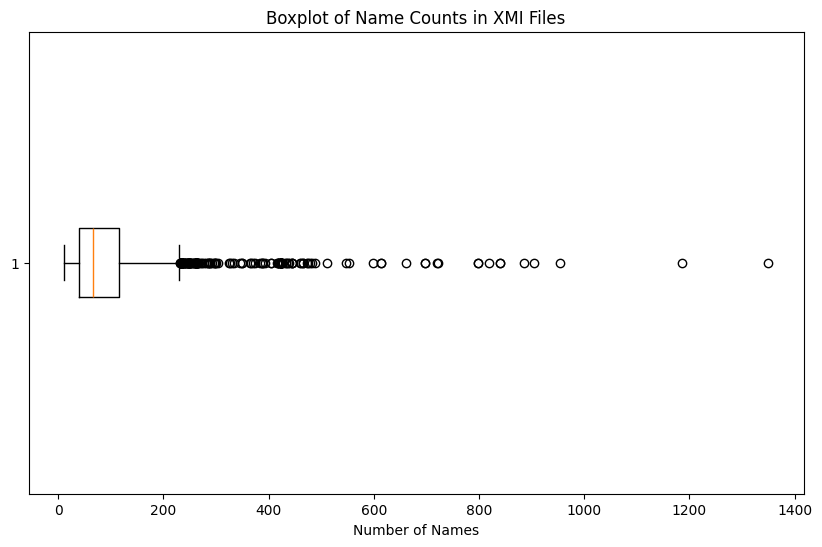

In [56]:
plt.figure(figsize=(10, 6))
plt.boxplot(df['Name Count'], vert=False)
plt.title('Boxplot of Name Counts in XMI Files')
plt.xlabel('Number of Names')
plt.show()

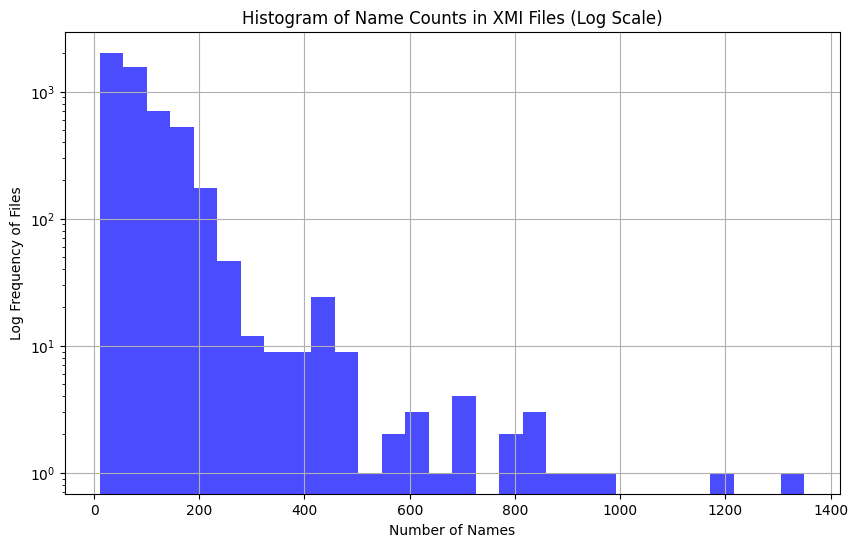

In [57]:
plt.figure(figsize=(10, 6))
plt.hist(df['Name Count'], bins=30, color='blue', alpha=0.7, log=True)
plt.title('Histogram of Name Counts in XMI Files (Log Scale)')
plt.xlabel('Number of Names')
plt.ylabel('Log Frequency of Files')
plt.grid(True)
plt.show()

Looking for models with only a few names

In [58]:
n = 5
few_names_df = df[df['Name Count'] < n]
few_names_df.shape

(0, 2)

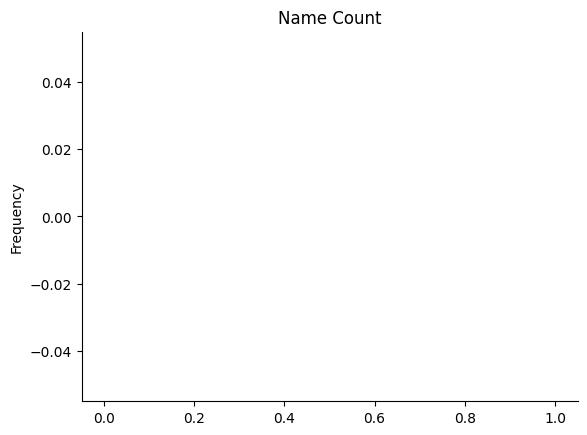

In [59]:
from matplotlib import pyplot as plt
few_names_df['Name Count'].plot(kind='hist', bins=20, title='Name Count')
plt.gca().spines[['top', 'right',]].set_visible(False)

Frequency of names

In [60]:
def load_names(directory):
    file_names_dict = {}
    for filename in os.listdir(directory):
        if filename.endswith(".txt"):
            file_path = os.path.join(directory, filename)
            with open(file_path, 'r', encoding="utf-8") as file:
                # Create a set of names from each file, stripping whitespace and converting to lowercase for uniformity
                names = {line.strip().lower() for line in file if line.strip()}  # Ensure non-empty lines
            file_names_dict[filename] = names
    return file_names_dict

names_dict = load_names(output_directory_without_type)

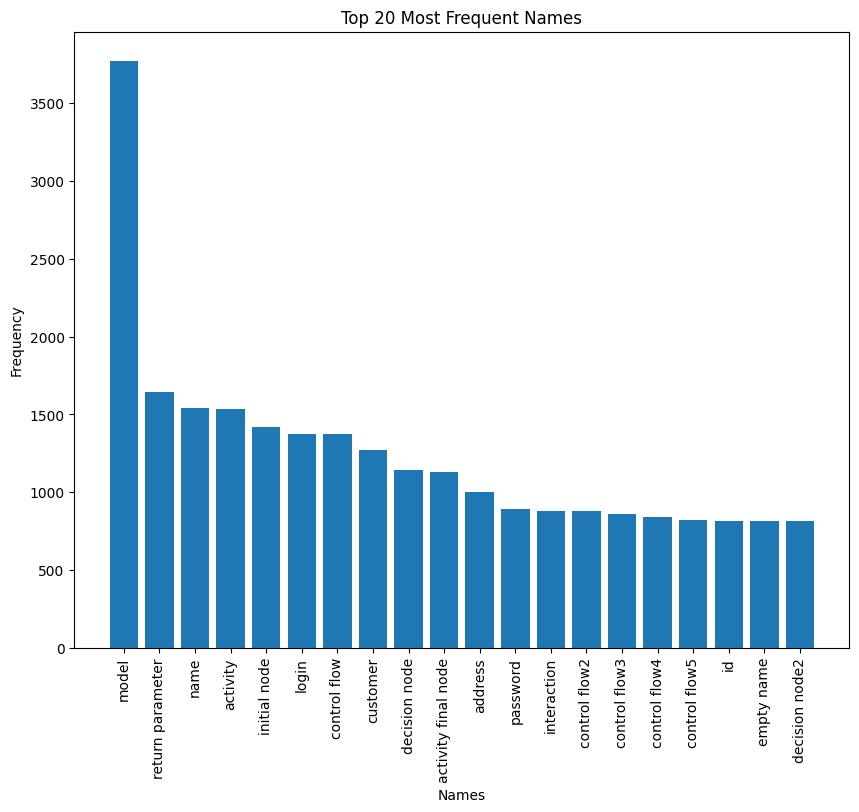

In [61]:
def plot_word_frequency(names_dict):
    all_names = [name for names in names_dict.values() for name in names]
    name_counts = Counter(all_names)
    most_common_names = name_counts.most_common(20)  # Get the top 20 most common names

    # Plotting
    plt.figure(figsize=(10, 8))
    names, counts = zip(*most_common_names)
    plt.bar(names, counts)
    plt.xlabel('Names')
    plt.ylabel('Frequency')
    plt.title('Top 20 Most Frequent Names')
    plt.xticks(rotation=90)
    plt.show()

plot_word_frequency(names_dict)

Median lenght of the names

In [62]:
def get_name_lengths(file_path):
    """Retrieve the mean and median length of names from a file."""
    with open(file_path, 'r', encoding="utf-8") as file:
        names = [line.strip() for line in file if line.strip()]
        if not names:  # Check if the list is empty
            return None, None  # Return None if no names are found

        lengths = [len(name) for name in names]  # Calculate lengths of each name
        mean_length = np.mean(lengths)
        median_length = np.median(lengths)

        return mean_length, median_length

def process_directory(directory):
    """Process all files in the specified directory and return a DataFrame with the results."""
    data = []

    # Loop over all files in the directory
    for filename in os.listdir(directory):
        if filename.endswith(".txt"):
            file_path = os.path.join(directory, filename)
            mean_length, median_length = get_name_lengths(file_path)
            if mean_length is not None and median_length is not None:  # Ensure there are names
                data.append((filename, mean_length, median_length))

    # Create DataFrame
    df = pd.DataFrame(data, columns=['File', 'Mean Length', 'Median Length'])
    return df

In [63]:
results_df = process_directory(output_directory_without_type)
results_df

,File,Mean Length,Median Length
0,002ca54a-bea9-469c-a218-94136d255e75.txt,9.500000,8.0
1,00319ae3-0244-4f26-bd98-982b1244fb50.txt,12.435897,13.0
2,005232b2-1223-4f5a-93a5-c32fb302a1fd.txt,13.576271,14.0
3,005741dc-cb8c-436d-bad7-4483a14bfb69.txt,9.407407,7.5
4,00804b8d-43fc-49cb-86ef-a1db731485b9.txt,12.537815,10.0
...,...,...,...
5115,__xiREBQKEeqDmNBP3mfLQg.txt,17.250000,12.0
5116,__Z-g8DNTEemjcq-iJCnVjQ.txt,11.363636,8.0
5117,___-M0L8xEeeEXb8Dudo6PQ.txt,8.119048,7.5
5118,___4B8HnhEemjiISbKferQg.txt,14.278481,13.0


In [64]:
m = 4
short_names_df = results_df[results_df['Median Length'] < m]
short_names_df.shape

(170, 3)

### Name Length Filter Consistency

In [65]:
from mcp4cm.uml.data_extraction import filter_models_by_name_length

filter_models_by_name_length(uml_dataset)

Filtering models by name length:   0%|          | 0/5120 [00:00<?, ?it/s]

Filtered out 170 models with short names.


Dataset(name=modelset, models=4950)

Above result shows name length filter consistency found: 170 with the results obtained without the library.

In [66]:
results_df[results_df['Median Length'] == m]

,File,Mean Length,Median Length
3068,_1P9sgO1hEei9dNtZPq67hQ.txt,3.882353,4.0
3232,_6LV20O1gEei9dNtZPq67hQ.txt,4.400000,4.0
3671,_EwAzIOm2EeiV94kHgjpOMg.txt,4.456522,4.0
3680,_F3qK8OmmEeiV94kHgjpOMg.txt,5.500000,4.0
3807,_GVEcwCNCEeisAYMSV00L2Q.txt,6.448980,4.0
4199,_MO_AwOmjEeiV94kHgjpOMg.txt,4.473684,4.0
4365,_p2Z6gAepEeqFfO0RhT_ZfA.txt,4.880000,4.0
4898,_xHohgOm5EeiJfugOH9Y5Zg.txt,4.736842,4.0


In [67]:
threshold_high_short_name = 0.30  # More than 30% of names must be short
threshold_low_short_name = 0.25  # At least 25% of names must be short
threshold_control_flow = 0.4  # At least 40% of names must contain "control flow"
min_name_length = 2  # Names of length 1 or 2 are considered short

def analyze_names(names):
    """ Analyze the names to categorize files based on criteria """
    short_names_count = 0
    control_flow_count = 0
    total_names = len(names)

    if total_names == 0:
        return (False, False)  # No names to analyze

    for name in names:
        if len(name.strip()) <= min_name_length:
            short_names_count += 1
        if "control flow" in name.lower():
            control_flow_count += 1

    short_name_ratio = short_names_count / total_names
    control_flow_ratio = control_flow_count / total_names

    criteria1 = short_name_ratio >= threshold_high_short_name
    criteria2 = short_name_ratio >= threshold_low_short_name and control_flow_ratio >= threshold_control_flow

    return (criteria1, criteria2)

single_char_names_criteria1 = []
single_char_names_criteria2 = []

# Iterate over files in the directory
for filename in os.listdir(output_directory_without_type):
    if filename.endswith(".txt"):
        file_path = os.path.join(output_directory_without_type, filename)
        with open(file_path, 'r', encoding="utf-8") as file:
            names = [line.strip() for line in file if line.strip()]  

        criteria1, criteria2 = analyze_names(names)
        if criteria1:
            single_char_names_criteria1.append(filename)
        if criteria2:
            single_char_names_criteria2.append(filename)

# Output results
print("Total Flagged models with >30% short names and no 'control flow':", len(single_char_names_criteria1))
# for model in single_char_names_criteria1:
#     print(model)

print("\nTotal Flagged models with >=25% short names and at least 40% 'control flow':", len(single_char_names_criteria2))
# for model in single_char_names_criteria2:
#     print(model)


Total Flagged models with >30% short names and no 'control flow': 194

Total Flagged models with >=25% short names and at least 40% 'control flow': 10


### Short names and stop words filter consistency

In [68]:
from mcp4cm.uml.data_extraction import filter_models_by_name_length_or_stopwords

filter_models_by_name_length_or_stopwords(uml_dataset)

Flagged models with > 30.0% short names: 194
Flagged models with >= 25.0% short names and >= 40.0% of stopwords: 10
Models After Filtering: 4926. Filtered: 194


Dataset(name=modelset, models=4926)

Above result shows short names and stop words filter found: 194 and with shortnames + stopwords found: 10 are consistency with the results obtained without the library.

In [69]:
two_char_pattern = re.compile(r'^[a-zA-Z]\d$', re.IGNORECASE)  # Matches "a1", "B2", etc.
letter_space_letter_pattern = re.compile(r'^[a-zA-Z]\s[a-zA-Z]$', re.IGNORECASE)  # Matches "a b", "x y", etc.

THRESHOLD = 0.3  # % of the names must be dummy to flag the model

# List to store flagged models with their dummy name percentage
matching_files = []

# Iterate through each text file in the directory
for filename in os.listdir(output_directory_without_type):
    if filename.endswith(".txt"):
        file_path = os.path.join(output_directory_without_type, filename)
        
        with open(file_path, "r", encoding="utf-8") as file:
            names = [line.strip() for line in file if line.strip()]  # Remove empty lines

            if not names:
                continue  # Skip empty name lists

            # Count how many names match dummy patterns
            dummy_count = sum(1 for name in names if two_char_pattern.match(name) or letter_space_letter_pattern.match(name))
            total_names = len(names)
            
            # Compute the percentage of dummy-like names
            dummy_ratio = dummy_count / total_names

            # Flag the file if the dummy ratio exceeds the threshold
            if dummy_ratio >= THRESHOLD:
                matching_files.append((filename, total_names, dummy_count, dummy_ratio))

# Sort flagged models by the highest dummy percentage
matching_files.sort(key=lambda x: x[3], reverse=True)

# Display the results
print(f"Total Flagged models based on dummy name percentage (Threshold: {THRESHOLD*100}%):", len(matching_files))
# for file, total, dummy, ratio in matching_files[:25]:  # Show first 10 for preview
#     print(f"{file} - {dummy}/{total} names ({ratio:.2%} dummy)")

# Save results to a file
output_file = "suspect_models_two_char_or_letter_space.txt" # Set a path where you want the results to be saved
with open(output_file, "w", encoding="utf-8") as f:
    f.write("Files containing at least one suspicious name ('a1', 'a b', etc.):\n")
    for file in matching_files:
        f.write(f"{file}\n")

print(f"Results saved to: {output_file}")
print("Number of flagged models:", len(matching_files))

Total Flagged models based on dummy name percentage (Threshold: 30.0%): 23
Results saved to: suspect_models_two_char_or_letter_space.txt
Number of flagged models: 23


### Two-character, Letter-space names filter consistency

In [70]:
from mcp4cm.uml.data_extraction import filter_dummy_short_names

filter_dummy_short_names(uml_dataset)

Filtering dummy short names:   0%|          | 0/5120 [00:00<?, ?it/s]

Flagged 23 models based on short dummy name percentage (Threshold: 30.0%)
Showing Top 10


Dataset(name=modelset, models=5097)

Above results shows the number of the two-character, letter-space names models found: 23 using the filter are consistent with the results obtained without the library.

In [71]:
# Extract only the filenames (first element of each tuple)
two_char_names = [entry[0] for entry in matching_files]

len(two_char_names)

23

In [72]:
# Regex pattern to match names like 'att1', 'att 1', 'attA', 'att A', etc.
# dummy_name_pattern = re.compile(r'^att\s+\d+|^att\s+[A-Za-z]$', re.IGNORECASE)

# dummy_name_pattern = re.compile(r'^att[a-z0-9]$', re.IGNORECASE)


dummy_name_pattern = re.compile(r'^att(\s+[A-Za-z]|\s+\d+|[a-z0-9])?$', re.IGNORECASE)

# Function to check files for dummy names
def find_files_with_dummy_names(directory, pattern):
    dummy_files = []
    for filename in os.listdir(directory):
        if filename.endswith(".txt"):
            file_path = os.path.join(directory, filename)
            with open(file_path, 'r', encoding="utf-8") as file:
                names = file.readlines()
                # Check if any name in the file matches the dummy pattern
                if any(pattern.match(name.strip()) for name in names):
                    dummy_files.append(filename)
    return dummy_files

files_with_dummies = find_files_with_dummy_names(output_directory_without_type, dummy_name_pattern)

print("Total Files with dummy names: ", len(files_with_dummies))
# for file in files_with_dummies:
#     print(file)
len(files_with_dummies)

Total Files with dummy names:  176


176

### Files with dummy names filter consistency

In [73]:
from mcp4cm.uml.data_extraction import filter_dummy_names

filter_dummy_names(uml_dataset)

Filtering dummy names:   0%|          | 0/5120 [00:00<?, ?it/s]

Flagged 176 models based on dummy name percentage (Threshold: 30.0%)
Showing Top 10


Dataset(name=modelset, models=4944)

The above result shows the number of models with dummy names found: 176 using the filter are consistent with the results obtained without the library.

In [74]:
# Regex patterns
dummy_class_pattern = re.compile(r'^class\s?[a-z0-9]$', re.IGNORECASE)  # Strictly match 'class 1', 'class a', etc.
general_class_pattern = re.compile(r'^[a-z]+', re.IGNORECASE)  # Match any class name


def classify_files(directory):
    files_fully_dummy = []
    files_mostly_valid = []
    files_mixed_classes = []

    for filename in os.listdir(directory):
        if filename.endswith(".txt"):
            file_path = os.path.join(directory, filename)
            dummy_count = 0
            valid_count = 0
            dummy_found = False  # Flag to check if any dummy name exists

            with open(file_path, 'r', encoding="utf-8") as file:
                for line in file:
                    type_name = line.strip().split(':')  # Splitting line into type and name
                    if len(type_name) < 2:  # Ensure there is a type and a name
                        continue
                    artifact_type, name = type_name[0].strip().lower(), type_name[1].strip()
                    if artifact_type == "class":  # Only process class types
                        if dummy_class_pattern.match(name):
                            dummy_count += 1
                            dummy_found = True  # Set flag on finding a dummy name
                        elif general_class_pattern.match(name):
                            valid_count += 1

            if dummy_found:  # Only process further if a dummy name was found
                # Evaluate file based on counts
                total_classes = dummy_count + valid_count
                if total_classes == 0:
                    continue  # Avoid division by zero, handle files with no class definitions

                dummy_ratio = dummy_count / total_classes
                # Define thresholds
                if dummy_ratio > 0.5:
                    files_fully_dummy.append(filename)
                elif dummy_count > 0 and dummy_ratio <= 0.13:  # Less than 13% dummy names
                    files_mixed_classes.append(filename)
                else:
                    files_mostly_valid.append(filename)

    return files_fully_dummy, files_mostly_valid, files_mixed_classes

# Classify files in the directory with type
fully_dummy, mostly_valid, mixed_classes = classify_files(output_directory_with_type)

# Display results
print("Total Files fully dummy:", len(fully_dummy))
# for file in fully_dummy:
#     print(file)

print("\nTotal Files mostly valid (with few dummy classes):", len(mostly_valid))
# for file in mostly_valid:
#     print(file)

print("\nTotal Files with a mix of dummy and non-dummy classes:", len(mixed_classes))
# for file in mixed_classes:
#     print(file)


Total Files fully dummy: 236

Total Files mostly valid (with few dummy classes): 16

Total Files with a mix of dummy and non-dummy classes: 13


In [75]:
mostly_valid

['5c7cf1d5-8cef-455c-a5bc-62cfc74d44a2.txt',
 'a2efefeb-3d2e-4e00-a927-e352fede338b.txt',
 'be4bf271-e094-43ca-b71d-2b5a7f1fe1ce.txt',
 '_3DvnUCH8EeqqcaoAsxFIeg.txt',
 '_48i_EL9vEemphpAvuifT8g.txt',
 '_8uGwcAlCEeqB3a4sRh-tuQ.txt',
 '_A7QHYOheEeiV94kHgjpOMg.txt',
 '_CPNAoEwiEeqonN_RS9oRzw.txt',
 '_ijfaIMHOEei9yqzfX9cFYA.txt',
 '_iPGWcGH0EeqK2M3E1LfZ7Q.txt',
 '_mjBXoMLHEei9yqzfX9cFYA.txt',
 '_mNc6IFrmEeiyA_1nwijzkg.txt',
 '_oE4JgIlxEeq3N_Xh6gsEIQ.txt',
 '_U_BUgOCuEee1VcqWCkiVQg.txt',
 '_V1-cwGSnEeio56zSTH7puw.txt',
 '_Z0GkwETJEeeTJ_4Vl2J2rQ.txt']

In [76]:
len(mostly_valid) + len(mixed_classes) + len(fully_dummy)

265

In [77]:
len(mostly_valid), len(mixed_classes), len(fully_dummy)

(16, 13, 236)

### Dummy class names filter consistency

In [78]:
from mcp4cm.uml.data_extraction import filter_dummy_classes

filter_dummy_classes(uml_dataset)

Filtering dummy classes:   0%|          | 0/5120 [00:00<?, ?it/s]

Flagged models based on dummy class percentage (Threshold: 50.0%)
Files fully dummy: 236
Files mostly valid (with few dummy classes): 16
Files with a mix of dummy and non-dummy classes: 13
Models After Filtering: 4868. Filtered: 252


Dataset(name=modelset, models=4868)

The above result shows that the number of files with dummy class names is consistent with the number of files with dummy class names found without the library.

In [79]:
# Regex pattern to match entries starting with "class:" followed by "my class" optionally followed by a space and number
pattern = re.compile(r'^class:\s*my class\s?(\d+)?$', re.IGNORECASE)

threshold = 2

# Dictionary to hold files and counts of occurrences
files_with_my_class_counts = {}

# Iterate over all text files in the directory
for filename in os.listdir(output_directory_with_type):
    if filename.endswith(".txt"):
        file_path = os.path.join(output_directory_with_type, filename)
        count = 0
        with open(file_path, 'r', encoding='utf-8') as file:
            # Read the file line by line
            for line in file:
                line = line.strip()
                if pattern.match(line):  # Check if the line matches the pattern
                    count += 1

        if count > threshold:  # Check if there are more than one occurrence
            files_with_my_class_counts[filename] = count

# Output results
print("Total Files containing more than one 'class: my class' or 'class: my class' followed by a number:", len(files_with_my_class_counts))
# for file, count in files_with_my_class_counts.items():
#     print(f"{file}: {count} occurrences")
len(files_with_my_class_counts)

Total Files containing more than one 'class: my class' or 'class: my class' followed by a number: 37


37

### My Class pattern filter consistency

In [80]:
from mcp4cm.uml.data_extraction import filter_classes_by_generic_pattern

filter_classes_by_generic_pattern(uml_dataset)

Filtering util classes:   0%|          | 0/5120 [00:00<?, ?it/s]

Files containing more than one 'class: my class' or 'class: my class' followed by a number:
Models After Filtering based on util class names (Threshold: 2)
Models After Filtering: 5083. Filtered: 37


Dataset(name=modelset, models=5083)

The above result shows that the number of files with generic classes name pattern is consistent with the number of files with generic classes names found without the library.

In [81]:
# Define common dummy words (extend as needed)
dummy_keywords = {"my class", "class", "use case", "actor", "attribute", "association", "control flow", "activity", "decision node", "opaque action",
                  "lifeline", "flow final node", "activity final node", "join node", "fork node", "initial node", "merge node", "action", "component", "ext point", "empty name", "package"}

# Define a regex to detect numbered patterns (e.g., "my class1", "association3")
numbered_pattern = re.compile(r'(.+?)[\s_]?(\d+)$', re.IGNORECASE)

# Define thresholds for detection
SEQUENTIAL_THRESHOLD = 0.75  # % of names that follow a sequential pattern
DUMMY_WORD_THRESHOLD = 0.82  # % of names that are util dummy words
VOCABULARY_UNIQUENESS_THRESHOLD = 3  # Minimum unique words per model

# Store flagged models
flagged_models = []

# Iterate over name files
for filename in os.listdir(output_directory_without_type):
    if filename.endswith(".txt"):
        file_path = os.path.join(output_directory_without_type, filename)
        with open(file_path, 'r', encoding="utf-8") as file:
            names = [line.strip().lower() for line in file if line.strip()]
        
        if not names:
            continue  # Skip empty files
        
        # Count occurrences of dummy words
        dummy_count = sum(1 for name in names if any(dw in name for dw in dummy_keywords))
        dummy_ratio = dummy_count / len(names)

        # Check for sequential naming patterns
        sequential_count = sum(1 for name in names if numbered_pattern.match(name))
        sequential_ratio = sequential_count / len(names)

        # Check vocabulary richness (count unique words)
        words = [word for name in names for word in name.split()]
        unique_words = set(words)

        # Flagging condition
        if (
            sequential_ratio >= SEQUENTIAL_THRESHOLD or  # Too many numbered names
            dummy_ratio >= DUMMY_WORD_THRESHOLD or  # Too many util words
            len(unique_words) <= VOCABULARY_UNIQUENESS_THRESHOLD  # Low vocabulary richness
        ):
            flagged_models.append((filename, len(names), sequential_ratio, dummy_ratio, len(unique_words)))

# Save flagged models to a file
output_file = "flagged_dummy_models.txt" # Set a path where you want the results to be saved
with open(output_file, "w") as f:
    f.write("File Name, Total Names, Sequential Ratio, Dummy Word Ratio, Unique Word Count\n")
    for model in flagged_models:
        f.write(f"{model[0]}, {model[1]}, {model[2]:.2f}, {model[3]:.2f}, {model[4]}\n")

print(f"Total Flagged dummy models saved to '{output_file}'", len(flagged_models))


Total Flagged dummy models saved to 'flagged_dummy_models.txt' 111


### Sequential or dummy word filter consistency

In [82]:
from mcp4cm.uml.data_extraction import filter_models_by_sequential_and_dummy_words

filter_models_by_sequential_and_dummy_words(uml_dataset)

Filtering sequential and dummy words:   0%|          | 0/5120 [00:00<?, ?it/s]

Flagged models based on sequential patterns (Threshold: 75.0%)
Flagged models based on dummy word percentage (Threshold: 82.0%)
Flagged models based on vocabulary uniqueness (Threshold: 3)
Models After Filtering: 5009. Filtered: 111


Dataset(name=modelset, models=5009)

The above result with 111 filtered models shows that the number of files with sequential or dummy words is consistent with the number of files with sequential or dummy words found without the library.

In [83]:
flagged_dummy_models = []

with open("flagged_dummy_models.txt", "r", encoding="utf-8") as f:
    next(f)  # Skip the header line
    for line in f:
        filename = line.split(",")[0].strip()  # Extract filename from CSV
        flagged_dummy_models.append(filename)  # Append to list

len(flagged_dummy_models)

111

In [84]:
# Function to process files, excluding the identified files
def process_files(directory, exclude_files):
    processed_files = []
    for filename in os.listdir(directory):
        if filename not in exclude_files:
            file_path = os.path.join(directory, filename)
            processed_files.append(file_path)
    return processed_files

In [85]:
files_with_few_names = few_names_df['File'].tolist()
files_with_short_names = short_names_df['File'].tolist()
files_with_my_class_names = list(files_with_my_class_counts.keys())


file_groups = {
    "files_with_dummies": files_with_dummies,
    "mostly_valid": mostly_valid,
    "fully_dummy": fully_dummy,
    "files_with_few_names": files_with_few_names,
    "files_with_short_names": files_with_short_names,
    "flagged_dummy_models": flagged_dummy_models,
    "files_with_my_class_names": files_with_my_class_names,
    "single_char_names_criteria1": single_char_names_criteria1,
    "single_char_names_criteria2": single_char_names_criteria2,
}


for name, group in file_groups.items():
    print(f"Processing {name}: {len(group)} files...")
    
# Combine all files to exclude into a set to ensure uniqueness
#files_to_exclude = set(files_with_dummies + mostly_valid + fully_dummy + files_with_few_names + files_with_short_names + flagged_dummy_models + two_char_names + files_with_my_class_names + single_char_names_criteria1 + single_char_names_criteria2)
files_to_exclude = set(files_with_dummies + mostly_valid + fully_dummy + files_with_few_names + files_with_short_names + flagged_dummy_models + files_with_my_class_names + single_char_names_criteria1 + single_char_names_criteria2)
all_files = set(os.listdir(output_directory_without_type))
# Process the dataset, excluding the files with dummy, specific class names, and few or too short names
remaining_files = process_files(output_directory_without_type, files_to_exclude)
len(remaining_files)

Processing files_with_dummies: 176 files...
Processing mostly_valid: 16 files...
Processing fully_dummy: 236 files...
Processing files_with_few_names: 0 files...
Processing files_with_short_names: 170 files...
Processing flagged_dummy_models: 111 files...
Processing files_with_my_class_names: 37 files...
Processing single_char_names_criteria1: 194 files...
Processing single_char_names_criteria2: 10 files...


4546

In [86]:
len(files_to_exclude)

574

### Applying all fitlers together and checking consistency

In [87]:
from mcp4cm.base import Dataset
from mcp4cm.uml.data_extraction import (
    filter_models_by_name_length,
    filter_models_by_name_count,
    filter_models_by_name_length_or_stopwords,
    filter_dummy_names,
    filter_dummy_classes,
    filter_classes_by_generic_pattern,
    filter_models_by_sequential_and_dummy_words
)
from mcp4cm.dataloading import load_dataset
from mcp4cm.base import DatasetType
import os


def get_models_dataset():
    uml_dataset = load_dataset(DatasetType.MODELSET, os.path.join('data', 'modelset'))

    Dataset.apply_filters(
        dataset=uml_dataset,
        filters=[
            filter_models_by_name_length_or_stopwords,
            filter_dummy_classes,
            filter_classes_by_generic_pattern,
            filter_dummy_names,
            filter_models_by_sequential_and_dummy_words,
            filter_models_by_name_length,
            filter_models_by_name_count,
        ],
        verbose=True
    )
    return uml_dataset

uml_dataset = get_models_dataset()
len(uml_dataset)

Loading UML models:   0%|          | 0/5120 [00:00<?, ?it/s]

Applying filter: filter_models_by_name_length_or_stopwords
Before filter: 5120
Flagged models with > 30.0% short names: 194
Flagged models with >= 25.0% short names and >= 40.0% of stopwords: 10
Models After Filtering: 4926. Filtered: 194
After filter: 4926
Applying filter: filter_dummy_classes
Before filter: 4926


Filtering dummy classes:   0%|          | 0/4926 [00:00<?, ?it/s]

Flagged models based on dummy class percentage (Threshold: 50.0%)
Files fully dummy: 236
Files mostly valid (with few dummy classes): 15
Files with a mix of dummy and non-dummy classes: 13
Models After Filtering: 4675. Filtered: 251
After filter: 4675
Applying filter: filter_classes_by_generic_pattern
Before filter: 4675


Filtering util classes:   0%|          | 0/4675 [00:00<?, ?it/s]

...

Filtering sequential and dummy words:   0%|          | 0/4636 [00:00<?, ?it/s]

Flagged models based on sequential patterns (Threshold: 75.0%)
Flagged models based on dummy word percentage (Threshold: 82.0%)
Flagged models based on vocabulary uniqueness (Threshold: 3)
Models After Filtering: 4546. Filtered: 90
After filter: 4546
Applying filter: filter_models_by_name_length
Before filter: 4546


Filtering models by name length:   0%|          | 0/4546 [00:00<?, ?it/s]

Filtered out 0 models with short names.
After filter: 4546
Applying filter: filter_models_by_name_count
Before filter: 4546
Models After Filtering with name counts between 5: 0
After filter: 4546


4546

The above results show that the number of models filtered after applying all filters is consistent with the number of models filtered without the library.

In [88]:
with open('dummy_files_to_exclude.txt', 'w') as file:
    # Write each ID without the .txt extension
    for filename in files_to_exclude:
        id_without_txt = filename.replace('.txt', '')
        file.write(id_without_txt + '\n')

Checking how many unique dummy models we found that aren't labeled as such in the dataset, and also how many we missed

In [89]:
# Extract just the file names (UUIDs) from dummy_models["id"]
dummy_model_ids = set(dummy_models["id"].str.extract(r'([^/]+)\.xmi$')[0].dropna())
unknown_model_ids = set(unknown_models["id"].str.extract(r'([^/]+)\.xmi$')[0].dropna())

# Extract just the file names (UUIDs) from files_to_exclude (remove .txt extension)
excluded_files = set(file.replace(".txt", "") for file in files_to_exclude)

# Find unique models in each list
unique_dummy_models = dummy_model_ids - excluded_files  # In dummy_models but NOT in files_to_exclude
unique_excluded_models = excluded_files - dummy_model_ids  # In files_to_exclude but NOT in dummy_models

# Print summary
print(f"Total dummy models: {len(dummy_model_ids)}")
print(f"Total excluded files: {len(excluded_files)}")
print(f"Unique dummy models (not in excluded): {len(unique_dummy_models)}")
print(f"Unique excluded models (not in dummy): {len(unique_excluded_models)}")

# Save results to files
with open("unique_dummy_models.txt", "w") as f:
    for model in unique_dummy_models:
        f.write(model + "\n")

with open("unique_excluded_models.txt", "w") as f:
    for model in unique_excluded_models:
        f.write(model + "\n")

print("Unique dummy models saved to 'unique_dummy_models.txt'")
print("Unique excluded models saved to 'unique_excluded_models.txt'")


Total dummy models: 606
Total excluded files: 574
Unique dummy models (not in excluded): 60
Unique excluded models (not in dummy): 28
Unique dummy models saved to 'unique_dummy_models.txt'
Unique excluded models saved to 'unique_excluded_models.txt'


In [90]:
# Find unique models in each list
unique_unknown_models = unknown_model_ids - excluded_files  # In unknown_models but NOT in files_to_exclude
unique_excluded_models_unknown = excluded_files - unknown_model_ids  # In files_to_exclude but NOT in unknown_models

13 models we found as dummy are tagged as unknown

In [91]:
len(unique_excluded_models_unknown)

561

Some cases for manual inspection

In [92]:
# Path to the file that contains the filenames
excluded_models_file = "unique_excluded_models.txt"

# Load filenames from the excluded models file
with open(excluded_models_file, "r", encoding="utf-8") as f:
    filenames = [line.strip() + ".txt" for line in f if line.strip()]  # Append .txt

# Regex pattern to match "control flow" and variations (e.g., "controlflow1", "control flow 1")
control_flow_pattern = re.compile(r'\bcontrol\s?flow\s?\d*\b', re.IGNORECASE)

# List to store filenames where "control flow" is NOT found in the content
files_without_control_flow = []

# Iterate over each file in the output directory
for filename in filenames:
    file_path = os.path.join(output_directory_without_type, filename)
    
    # Check if the file exists in the directory before reading
    if os.path.exists(file_path):
        with open(file_path, "r", encoding="utf-8") as file:
            content = file.read()
            # If "control flow" is NOT found in the content, add to the list
            if not control_flow_pattern.search(content):
                files_without_control_flow.append(filename)

# Print results
print(f"Total files checked: {len(filenames)}")
print(f"Files without 'control flow': {len(files_without_control_flow)}")

Total files checked: 28
Files without 'control flow': 11


In [93]:
files_without_control_flow

['_X1iQ4MUeEeeWu-SLkciAbg.txt',
 'a2efefeb-3d2e-4e00-a927-e352fede338b.txt',
 '_XhxOMPJXEei0SKJPiR2ViA.txt',
 '_8uGwcAlCEeqB3a4sRh-tuQ.txt',
 '_V1-cwGSnEeio56zSTH7puw.txt',
 '_MBZ9oPbFEeeL5uCiN2F57w.txt',
 'be4bf271-e094-43ca-b71d-2b5a7f1fe1ce.txt',
 '_iPGWcGH0EeqK2M3E1LfZ7Q.txt',
 '_YtZi0NjvEeeQi8PFukjNiw.txt',
 '_CPNAoEwiEeqonN_RS9oRzw.txt',
 '_oE4JgIlxEeq3N_Xh6gsEIQ.txt']

# Duplicate detection

### Hashing for exact duplicates

In [94]:
def get_file_hash(file_path):
    """Compute a SHA-256 hash for the extracted UML names stored in a text file."""
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            content = file.read().strip().lower()  # Read and normalize text content
            # print(content)
            return hashlib.sha256(content.encode()).hexdigest()  # Hash the content
    except Exception as e:
        print(f"Error reading file {file_path}: {e}")
        return None

In [95]:
hash_to_files = defaultdict(list)
output_txt_file = "hashing_results.txt"

start_time = time.time()

for file_name in os.listdir(output_directory_with_type):
    # if file_name.endswith(".txt") and file_name not in files_to_exclude:
    if file_name.endswith(".txt"):
        file_path = os.path.join(output_directory_with_type, file_name)
        file_hash = get_file_hash(file_path)
        # print(file_path, file_hash)  # Print the file path and its hash for debugging

        if file_hash:
            hash_to_files[file_hash].append(file_path)

end_time = time.time()
execution_time = end_time - start_time

duplicate_files = {h: files for h, files in hash_to_files.items() if len(files) > 1}
unique_files = {h: files[0] for h, files in hash_to_files.items() if len(files) == 1}

# Save results to a text file
with open(output_txt_file, 'w', encoding='utf-8') as txt_file:
    txt_file.write(f"Execution time: {execution_time:.2f} seconds\n\n")
    txt_file.write("=== Duplicate UML Name Files Detected ===\n")
    if duplicate_files:
        for file_hash, files in duplicate_files.items():
            txt_file.write(f"\nDuplicate Group (Hash: {file_hash}):\n")
            for file in files:
                txt_file.write(f"  - {os.path.basename(file)}\n")
    else:
        txt_file.write("No duplicate name files found.\n")

    txt_file.write("\n=== Unique UML Name Files (No Duplicates) ===\n")
    if unique_files:
        for file_hash, file in unique_files.items():
            txt_file.write(f"\nUnique File (Hash: {file_hash}):\n  - {os.path.basename(file)}\n")
    else:
        txt_file.write("No unique files found.\n")

# Print execution time
print(f"\nExecution time: {execution_time:.2f} seconds")
print(f"Results saved to: {output_txt_file}")


Execution time: 0.36 seconds
Results saved to: hashing_results.txt


In [96]:
hash_to_files = defaultdict(list)
output_txt_file = "hashing_results.txt"

start_time = time.time()

for file_name in os.listdir(output_directory_with_type):
    # if file_name.endswith(".txt") and file_name not in files_to_exclude:
    if file_name.endswith(".txt"):
        file_path = os.path.join(output_directory_with_type, file_name)
        file_hash = get_file_hash(file_path)
        # print(file_path, file_hash)  # Print the file path and its hash for debugging

        if file_hash:
            hash_to_files[file_hash].append(file_path)
        print(file_path, file_hash)
        # break

end_time = time.time()
execution_time = end_time - start_time

duplicate_files = {h: files for h, files in hash_to_files.items() if len(files) > 1}
unique_files = {h: files[0] for h, files in hash_to_files.items() if len(files) == 1}

modelset_uml_names_with_type\002ca54a-bea9-469c-a218-94136d255e75.txt aa5f77b00233e8cb022847ae2dbaa45d336bc1e007839dbecb1912c9316e86e0
modelset_uml_names_with_type\00319ae3-0244-4f26-bd98-982b1244fb50.txt 339a626349ca33727775d848456e849d983c6cf17fa6cd737c5201c3b91b16f7
modelset_uml_names_with_type\005232b2-1223-4f5a-93a5-c32fb302a1fd.txt 85384d2a30cbdced1e2ee7684dfaabe3b928211447e6c7000edad29f2b77eae7
modelset_uml_names_with_type\005741dc-cb8c-436d-bad7-4483a14bfb69.txt f883d754a62590fa5363a4b8e3f0dd9f25085a1c169e2a7a33d04ba679f79d08
modelset_uml_names_with_type\00804b8d-43fc-49cb-86ef-a1db731485b9.txt 7b06dc5c91456f0a09044300c25544e89fe9fa59168a99bf28ffc5cc99e82d36
modelset_uml_names_with_type\009c586e-c334-44e9-bc54-cda8cd222031.txt 5d4e553ca078b76117cab4efa163fcaf4168105e22d2b31dc447b705e2841c64
modelset_uml_names_with_type\0101a158-d77f-4c1c-b888-de3d1c9fb423.txt 94b0a9ba4744f8d46e59a015abc8eabbda167532250ffead87da1e6d1ba02c14
modelset_uml_names_with_type\012040e0-9008-4c6f-9116-8b

In [97]:
len(duplicate_files), len(unique_files)

(376, 2701)

Pie chart shows 'unique files' vs the 'number of files found in the duplicate groups'. There's 376 distinct groups into which the duplicates are categorized, so technicaly a total amount of unique files would be 'unique files' + one representative of each duplicate group.


=== Dataset Statistics ===
Total files processed: 5120
Total unique files: 2701
Total duplicate files: 2419
Number of duplicate groups: 376


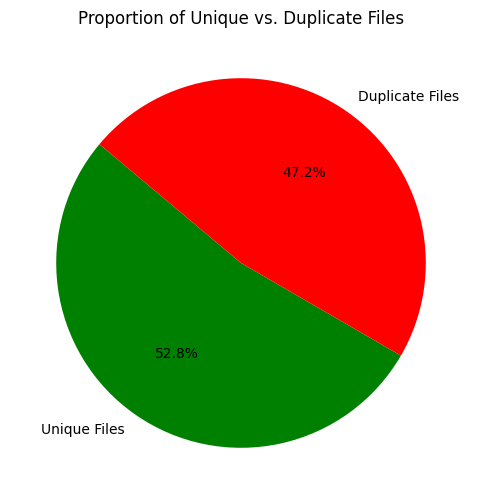

In [98]:
# Path to the output file
output_txt_file = "hashing_results.txt"

# Data structures to store parsed results
duplicate_counts = []
unique_list = []
total_files = 0
total_duplicates = 0
total_unique = 0

# Read the results from the text file
with open(output_txt_file, 'r', encoding='utf-8') as file:
    lines = file.readlines()

# Parse the file contents
current_duplicate_group_size = 0
parsing_duplicates = False
parsing_uniques = False

for line in lines:
    line = line.strip()

    # Detect the start of duplicate groups
    if "=== Duplicate UML Name Files Detected ===" in line:
        parsing_duplicates = True
        continue

    # Detect the start of unique files
    if "=== Unique UML Name Files" in line:
        parsing_duplicates = False
        parsing_uniques = True
        continue

    # Process duplicate groups
    if parsing_duplicates:
        if line.startswith("Duplicate Group (Hash:"):
            # Store the previous group size
            if current_duplicate_group_size > 0:
                duplicate_counts.append(current_duplicate_group_size)
            current_duplicate_group_size = 0  # Reset for next group
        elif line.startswith("-"):
            current_duplicate_group_size += 1  # Count files in group

    # Process unique files
    if parsing_uniques and line.startswith("-"):
        unique_list.append(line.split("-")[-1].strip())

# Store the last duplicate group size
if current_duplicate_group_size > 0:
    duplicate_counts.append(current_duplicate_group_size)

# Compute total counts
total_duplicates = sum(duplicate_counts)
total_unique = len(unique_list)
total_files = total_duplicates + total_unique

# Print statistics
print("\n=== Dataset Statistics ===")
print(f"Total files processed: {total_files}")
print(f"Total unique files: {total_unique}")
print(f"Total duplicate files: {total_duplicates}")
print(f"Number of duplicate groups: {len(duplicate_counts)}")


labels = ['Unique Files', 'Duplicate Files']
sizes = [total_unique, total_duplicates]
colors = ['green', 'red']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title("Proportion of Unique vs. Duplicate Files")
plt.show()

In [99]:
def read_file(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            return file.read().strip()
    except Exception as e:
        print(f"Error reading file {file_path}: {e}")
        return None

files_content = []
filenames = []

# Add one representative from each duplicate group
for file_paths in duplicate_files.values():
    representative_file = file_paths[0]  # Just take the first file as the representative
    content = read_file(representative_file)
    if content:
        files_content.append(content)
        filenames.append(representative_file)

# Add all unique files
for file_path in unique_files.values():
    content = read_file(file_path)
    if content:
        files_content.append(content)
        filenames.append(file_path)

In [100]:
file_path

'modelset_uml_names_with_type\\___VosLikEeehVczkwiTSNA.txt'

After finding the exact duplicates, we take the 'unique files' + one representative of each duplicate group, and do near-duplicate detection to also remove items that are not exactly identical but share substantial similarities, such as a base model with minor modifications (like an additional class for example). This is done with tf-idf representation + cosine similarity.
The txt file that stores the results this time under the  "=== Unique Files ===" tag stores truly uniqe files, as well as one representative fo each duplicate group!

In [101]:
start_time = time.time()

# Compute TF-IDF vectors
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(files_content)

# Compute cosine similarity matrix
similarity_matrix = cosine_similarity(tfidf_matrix)

# Set a similarity threshold
similarity_threshold = 0.8

# Initialize groups of duplicates
duplicate_groups = defaultdict(list)
unique_files_indices = set(range(len(filenames)))  # Track indices of potentially unique files

# Efficient file comparison
for i in range(len(filenames)):
    found_group = False
    file1 = os.path.basename(filenames[i])

    for group_id, members in list(duplicate_groups.items()):
        for member_index in members:
            if member_index != i and similarity_matrix[i][member_index] > similarity_threshold:
                duplicate_groups[group_id].append(i)
                found_group = True
                unique_files_indices.discard(i)  # Remove from unique files if found duplicate
                break
        if found_group:
            break

    # If no existing group is similar, start a new group
    if not found_group and i in unique_files_indices:
        duplicate_groups[file1].append(i)

# Write results
near_duplicate_file = "near_duplicate_results.txt"
with open(near_duplicate_file, 'w', encoding='utf-8') as file:
    file.write("=== Near Duplicate Files Detected ===\n")
    for group_id, indices in duplicate_groups.items():
        if len(indices) > 1:
            file.write(f"\n{group_id} has the following near duplicates:\n")
            for index in indices:
                file_name = os.path.basename(filenames[index])
                if file_name != group_id:
                    file.write(f"  - {file_name}\n")

    file.write("\n=== Unique Files ===\n")
    for index in unique_files_indices:
        file.write(f"  - {os.path.basename(filenames[index])}\n")

execution_time = time.time() - start_time
print(f"\nExecution time for near duplicate search: {execution_time:.2f} seconds")
print(f"Results saved to: {near_duplicate_file}")


Execution time for near duplicate search: 1.15 seconds
Results saved to: near_duplicate_results.txt



=== Dataset Statistics ===
Total files processed: 3077
Total unique files: 1107
Total duplicate files: 1970
Number of duplicate groups: 248


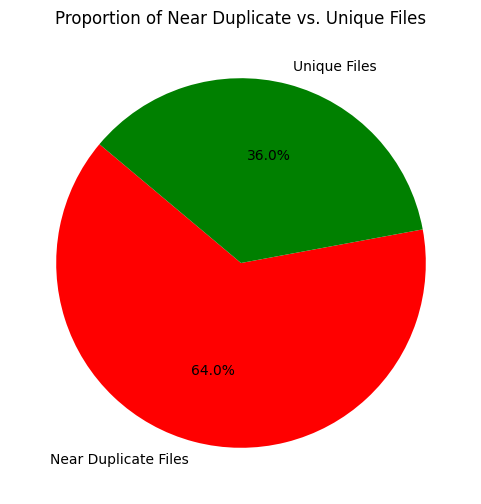

In [102]:
# Count the number of near duplicates and unique files
near_duplicate_count = sum(len(indices) for indices in duplicate_groups.values() if len(indices) > 1)
number_of_duplicate_groups = sum(1 for indices in duplicate_groups.values() if len(indices) > 1)
unique_file_count = len(unique_files_indices) - number_of_duplicate_groups
total_files_processed = near_duplicate_count + unique_file_count

# Print dataset statistics
print("\n=== Dataset Statistics ===")
print(f"Total files processed: {total_files_processed}")
print(f"Total unique files: {unique_file_count}")
print(f"Total duplicate files: {near_duplicate_count}")
print(f"Number of duplicate groups: {number_of_duplicate_groups}")

# Labels and sizes for the pie chart
labels = ['Near Duplicate Files', 'Unique Files']
sizes = [near_duplicate_count, unique_file_count]
colors = ['red', 'green']

# Create the pie chart
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title("Proportion of Near Duplicate vs. Unique Files")
plt.show()


# Language detection

In [103]:
def process_file(file_path):
    """Process a single txt file to detect language."""
    language_counts = defaultdict(int)
    file_languages = set()

    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            text = file.read()

        if text.strip():  # Ensure it's not empty or whitespace
            detected_language = detect(text)
            language_counts[detected_language] += 1
            file_languages.add(detected_language)
    except Exception as e:
        print(f"Error processing file {file_path}: {e}")

    return file_path, language_counts, file_languages

In [104]:
# Ensure consistent results from langdetect
DetectorFactory.seed = 42

# Directory containing the text files
directory = "modelset_uml_names"
# File to save results
result_file_path = "language_detection_results_modelset.txt" # Define your path where you want your results

# List all text files in the directory
file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".txt")]

# Process files sequentially
all_language_counts = defaultdict(int)
files_with_languages = defaultdict(set)

for file_path in file_paths:
    _, language_counts, file_languages = process_file(file_path)
    for lang, count in language_counts.items():
        all_language_counts[lang] += count
    files_with_languages[file_path].update(file_languages)

# Write results to a text file
with open(result_file_path, 'w', encoding='utf-8') as result_file:
    result_file.write("=== Language Distribution Across Dataset ===\n")
    for language, count in all_language_counts.items():
        result_file.write(f"{language}: {count}\n")

    result_file.write("\n=== Files with Detected Languages ===\n")
    for file, languages in files_with_languages.items():
        result_file.write(f"{file}: {', '.join(languages) if languages else 'No language detected'}\n")

print(f"\nLanguage detection completed. Results saved to '{result_file_path}'.")



Language detection completed. Results saved to 'language_detection_results_modelset.txt'.


In [105]:
summary_file = "language_detection_results_modelset.txt"

In [106]:
def extract_non_english_files(summary_file):
    non_english_files = []
    parsing_languages = False

    with open(summary_file, 'r', encoding='utf-8') as file:
        for line in file:
            if line.strip() == "=== Files with Detected Languages ===":
                parsing_languages = True
            elif parsing_languages and line.strip():
                parts = line.split(':')
                file_path = parts[0].strip()
                language = parts[1].strip()
                # Extract only the filename from the path
                filename = file_path.split('/')[-1]
                # Check if English is not the detected language
                if language != 'en':
                    non_english_files.append(filename)

    return non_english_files

Checking the difference in numbers of the detected English models and the ones thatw ere labeled as such

In [107]:
english_models_df

,id,domain,tags,language,purpose,simplified_id
0,repo-genmymodel-uml/data/64d73a9a-d42d-4090-b6...,travel,NaN,english,unknown,64d73a9a-d42d-4090-b6ce-9496e444dcf0
1,repo-genmymodel-uml/data/eb2e3754-86b5-4347-84...,store,NaN,english,unknown,eb2e3754-86b5-4347-8434-71e3135183f5
2,repo-genmymodel-uml/data/484652f6-e5a4-46ab-be...,computer,api|api,english,unknown,484652f6-e5a4-46ab-befb-dfb8f7641371
3,repo-genmymodel-uml/data/437ab337-a90b-4f71-b6...,computer,api|api,english,unknown,437ab337-a90b-4f71-b624-4453324e5fa9
4,repo-genmymodel-uml/data/be831d41-e22f-4096-86...,shopping,NaN,english,comercial,be831d41-e22f-4096-86a1-336770a46d93
...,...,...,...,...,...,...
5115,repo-genmymodel-uml/data/15eeaaf5-edea-4355-a5...,booking,NaN,english,unknown,15eeaaf5-edea-4355-a546-cb6748d9f563
5116,repo-genmymodel-uml/data/e7a6aab2-9695-4ab2-97...,restaurant,hierarchy,english,unknown,e7a6aab2-9695-4ab2-97c3-9ae2cbeccf8b
5117,repo-genmymodel-uml/data/2dd271e1-4923-4a0b-b7...,booking,restaurant,english,unknown,2dd271e1-4923-4a0b-b70c-2d3523493a84
5118,repo-genmymodel-uml/data/b202a006-e9dc-4cd5-af...,health,hospital,english,unknown,b202a006-e9dc-4cd5-af2c-ea250c57c63e


In [108]:
english_files_labeled = english_models_df["simplified_id"].tolist()

In [109]:
len(english_files_labeled)

4497

In [110]:
def extract_english_files(summary_file):
    english_files = []
    parsing_languages = False

    with open(summary_file, 'r', encoding='utf-8') as file:
        for line in file:
            if line.strip() == "=== Files with Detected Languages ===":
                parsing_languages = True
            elif parsing_languages and line.strip():
                parts = line.split(':')
                file_path = parts[0].strip()
                language = parts[1].strip()
                # Extract only the filename from the path
                filename = file_path.split('/')[-1]
                # Check if English is not the detected language

                if language == 'en':
                    english_files.append(filename)

    return english_files

In [111]:
english_files = extract_english_files(summary_file)
english_files = [os.path.basename(file) for file in english_files]

In [112]:
english_files

['002ca54a-bea9-469c-a218-94136d255e75.txt',
 '00319ae3-0244-4f26-bd98-982b1244fb50.txt',
 '005232b2-1223-4f5a-93a5-c32fb302a1fd.txt',
 '005741dc-cb8c-436d-bad7-4483a14bfb69.txt',
 '00804b8d-43fc-49cb-86ef-a1db731485b9.txt',
 '009c586e-c334-44e9-bc54-cda8cd222031.txt',
 '0135a497-5a9f-4032-b123-eaca643929e9.txt',
 '0147ca54-a618-4801-848d-d1eb35c894e1.txt',
 '0168e18b-5474-44f5-b26c-eeb8e190f382.txt',
 '017c44d4-8411-4119-9034-276940fd859b.txt',
 '01933ada-508b-4ae6-9d66-36352594013b.txt',
 '01a633d1-e68f-42c5-9bfe-20c3f305238c.txt',
 '01d8334c-c7f6-48e4-b3e7-4f72224ddbfd.txt',
 '01f98f2d-03a9-4998-90de-88d830d460e6.txt',
 '02210c0f-1b01-4f84-b5ce-ac64d4295ba9.txt',
 '02215e76-e093-4888-8efc-dad5d6ea5c1b.txt',
 '023dadfd-ea30-4ea7-9de5-68ee829d327c.txt',
 '026af861-f4c0-431c-9e00-c28743088ee4.txt',
 '028d758f-d6e9-4580-b0c5-83f928ac0a53.txt',
 '02c46879-5dcd-484e-a106-bb6ddf616d17.txt',
 '02c4d4d4-a521-4df9-a341-451518e9dc6a.txt',
 '032c334d-a24a-4757-835f-2b15911226fb.txt',
 '034d066d

In [113]:
english_files = [re.search(r'([\w-]+)\.txt', filename).group(1) for filename in english_files if re.search(r'([\w-]+)\.txt', filename)]

In [114]:
english_files

['002ca54a-bea9-469c-a218-94136d255e75',
 '00319ae3-0244-4f26-bd98-982b1244fb50',
 '005232b2-1223-4f5a-93a5-c32fb302a1fd',
 '005741dc-cb8c-436d-bad7-4483a14bfb69',
 '00804b8d-43fc-49cb-86ef-a1db731485b9',
 '009c586e-c334-44e9-bc54-cda8cd222031',
 '0135a497-5a9f-4032-b123-eaca643929e9',
 '0147ca54-a618-4801-848d-d1eb35c894e1',
 '0168e18b-5474-44f5-b26c-eeb8e190f382',
 '017c44d4-8411-4119-9034-276940fd859b',
 '01933ada-508b-4ae6-9d66-36352594013b',
 '01a633d1-e68f-42c5-9bfe-20c3f305238c',
 '01d8334c-c7f6-48e4-b3e7-4f72224ddbfd',
 '01f98f2d-03a9-4998-90de-88d830d460e6',
 '02210c0f-1b01-4f84-b5ce-ac64d4295ba9',
 '02215e76-e093-4888-8efc-dad5d6ea5c1b',
 '023dadfd-ea30-4ea7-9de5-68ee829d327c',
 '026af861-f4c0-431c-9e00-c28743088ee4',
 '028d758f-d6e9-4580-b0c5-83f928ac0a53',
 '02c46879-5dcd-484e-a106-bb6ddf616d17',
 '02c4d4d4-a521-4df9-a341-451518e9dc6a',
 '032c334d-a24a-4757-835f-2b15911226fb',
 '034d066d-a498-44d9-80a3-95e1a6cf5994',
 '03736215-ef06-40b0-99bc-dfa8bdb4d35b',
 '038a6b1d-f9aa-

In [115]:
len(english_files)

4443

In [116]:
unique_labeled = set(english_files_labeled) - set(english_files)

In [117]:
len(unique_labeled)

273

In [118]:
unique_ours = set(english_files) - set(english_files_labeled)

In [119]:
len(unique_ours)

219

Extarcting non-English files to add to the exclusion list

In [120]:
# Extract non-English files from the summary and update the exclusion list
non_english_files = extract_non_english_files(summary_file)
non_english_files = [os.path.basename(file) for file in non_english_files]

In [121]:
len(non_english_files)

677

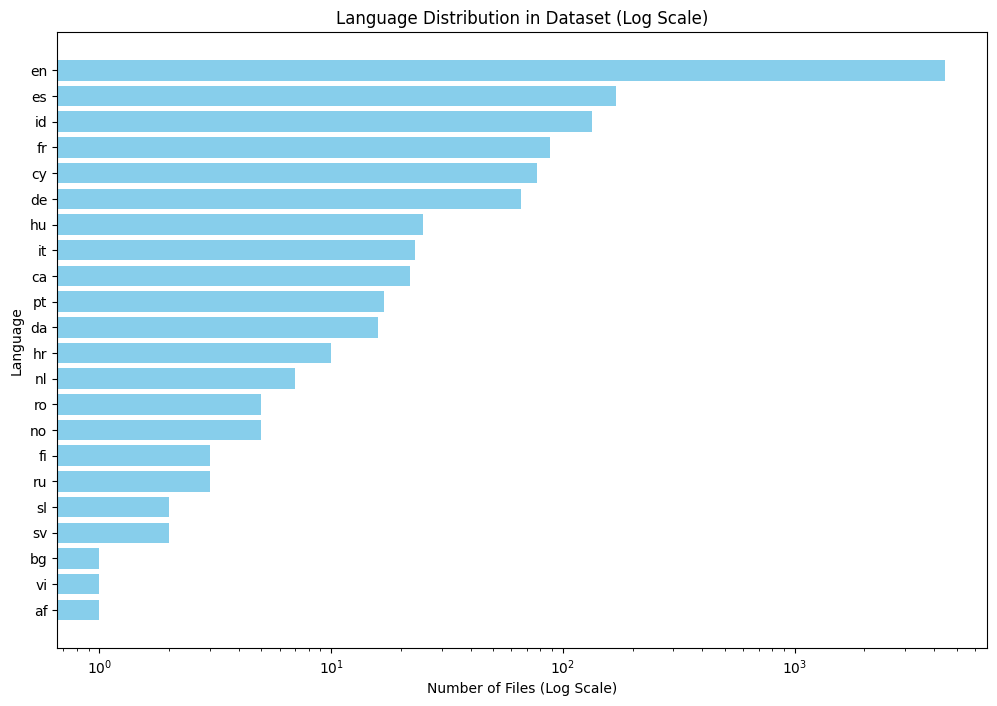

In [122]:
def extract_language_counts(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        lines = file.readlines()
    
    # Start reading the file after this line
    start_index = lines.index("=== Language Distribution Across Dataset ===\n") + 1
    end_index = lines.index("=== Files with Detected Languages ===\n")
    
    language_counts = {}
    for line in lines[start_index:end_index]:
        if ":" in line:
            language, count = line.strip().split(":")
            language_counts[language.strip()] = int(count.strip())
    
    return language_counts

# Extract language counts from file
language_counts = extract_language_counts(summary_file)

# Convert to DataFrame for easier plotting
df_languages = pd.DataFrame(list(language_counts.items()), columns=['Language', 'Count'])

# Sort the DataFrame by count for better visualization
df_languages.sort_values('Count', ascending=False, inplace=True)

# Plotting
plt.figure(figsize=(12, 8))
plt.barh(df_languages['Language'], df_languages['Count'], color='skyblue')
plt.xlabel('Number of Files (Log Scale)')
plt.ylabel('Language')
plt.title('Language Distribution in Dataset (Log Scale)')
plt.xscale('log')  # Set the x-axis to a log scale
plt.gca().invert_yaxis()  # Invert y axis to have the highest count at the top
plt.show()

In [123]:
# Remove '.txt' extension and convert to a set
non_english_files_set = {file[:-4] for file in non_english_files}

# Compute the difference
remaining_ids = unique_unknown_models.difference(non_english_files_set)

# Output the remaining unique unknown model IDs
remaining_ids

{'0dfed87f-aee3-4b53-b0eb-516c93a001d7',
 '144782cb-cfe0-4cb3-b542-23e465f8dc71',
 '2fac5aeb-4470-4506-b247-c791421c8b6e',
 '31751b83-b990-492f-a5f1-a5285dce0d13',
 '3a1fe8fa-916f-4c40-90f5-219b75c98232',
 '3ad16260-3ca7-439e-ace4-e204fa0c7bd9',
 '59037aa5-bf07-4b06-a042-41f763e276f7',
 '59fb5ee2-0bb9-4e13-a66e-46c82355ca9d',
 '69133377-e295-4e99-ad2a-371a8bfa0f77',
 '774a0070-f9b6-415c-b852-cda24c6ddc81',
 '78f3cf14-b6de-4daf-8397-c27fd2c24e1f',
 '7fcb8a92-8971-48b4-b800-f3f958fc4338',
 '8a2420c6-8bef-4d19-8b4e-6665feb0f5bb',
 '907bf4df-5757-4245-b266-9d37aa6d82a3',
 '90a3e48a-a0b1-44fb-a9f9-cfb8bfa05b57',
 '987a342a-495b-41eb-ae6b-01ddf64a7c51',
 '98cc9d19-6b56-4692-bc8a-62d47b6c4aa6',
 '_-4cScMoFEeeM1PgT03-3Vg',
 '_-RgCUDpsEemHAp3Hj3YZWw',
 '_0Gtw8BpmEeqPCsas7676rw',
 '_0pvHsD1REei384rcaJKdxw',
 '_0r5yAN9oEemZHaiox11UDg',
 '_1I-m4OKYEee1VcqWCkiVQg',
 '_20oEcMfWEeiZ3fREAmKE6g',
 '_26n44MPGEeeWu-SLkciAbg',
 '_28W4UD1WEei-35aR1OYsWA',
 '_2D8DMN3KEeeAyLDAJ12_fg',
 '_2g8ZcNXhEeehRMl7r1-c

In [124]:
len(remaining_ids)

199

# Extracting datasets for the reproducibility study 

As needed for the paper "Can explainable artificial intelligence support software modelers in model comprehension?": just removing duplicates

In [125]:
# Path to the text file containing the near duplicate results
results_file_path = "near_duplicate_results.txt"

# List to hold the unique file names
unique_file_names = []

# Flag to determine if we are in the section containing unique file names
parsing_uniques = False

# Open the file and read line by line
with open(results_file_path, 'r', encoding='utf-8') as file:
    for line in file:
        # Check if we've reached the section with unique file names
        if '=== Unique Files ===' in line:
            parsing_uniques = True
            continue
        elif parsing_uniques:
            if line.startswith('  - '):  # Unique file names are prefixed with "  - "
                # Extract the file name and add to the list
                
                file_name = line.strip()[2:-4]
                unique_file_names.append(file_name)

In [126]:
len(unique_file_names)

1355

In [127]:
# Add a new column that simplifies the 'id' for matching
merged_df['simplified_id'] = merged_df['id'].str.extract(r'data/([^.]+)')

# Filter the DataFrame to only include rows where the simplified ID is in the filtered_unique_files list
filtered_df = merged_df[merged_df['simplified_id'].isin(unique_file_names)]

filtered_df

,id,diagram_ad,diagram_cd,diagram_comp,diagram_interaction,diagram_sm,diagram_usecase,elements,category,tags,language,simplified_id
0,repo-genmymodel-uml/data/_WJKFoOBcEeeAyLDAJ12_...,1.0,5.0,NaN,NaN,NaN,1.0,123.0,computer-ui,NaN,english,_WJKFoOBcEeeAyLDAJ12_fg
1,repo-genmymodel-uml/data/_grOBAOs7EeiJfugOH9Y5...,NaN,8.0,NaN,NaN,NaN,NaN,56.0,computer-videogames,videgame,english,_grOBAOs7EeiJfugOH9Y5Zg
2,repo-genmymodel-uml/data/_zRSRMDEsEemjcq-iJCnV...,NaN,3.0,NaN,NaN,NaN,NaN,32.0,unknown,NaN,unknown,_zRSRMDEsEemjcq-iJCnVjQ
4,repo-genmymodel-uml/data/_xxwCoJSgEeiilJ4tAEXZ...,NaN,9.0,NaN,NaN,NaN,NaN,87.0,course,courses|teaching,english,_xxwCoJSgEeiilJ4tAEXZQQ
5,repo-genmymodel-uml/data/_1oIk0CMrEemOV5tdt4HL...,NaN,8.0,NaN,NaN,NaN,NaN,52.0,computer-videogames,NaN,english,_1oIk0CMrEemOV5tdt4HL0w
...,...,...,...,...,...,...,...,...,...,...,...,...
2606,repo-genmymodel-uml/data/6508e918-17c5-426f-a0...,NaN,12.0,NaN,NaN,NaN,2.0,171.0,booking-flight,NaN,english,6508e918-17c5-426f-a0aa-46c227f024c0
2607,repo-genmymodel-uml/data/_73KhUNGGEeib2vfQ4l86...,NaN,NaN,NaN,NaN,NaN,3.0,112.0,bank,NaN,spanish,_73KhUNGGEeib2vfQ4l86Yg
2608,repo-genmymodel-uml/data/_09BW0PJNEei0SKJPiR2V...,NaN,8.0,NaN,NaN,NaN,NaN,91.0,dummy,NaN,english,_09BW0PJNEei0SKJPiR2ViA
2615,repo-genmymodel-uml/data/_UBxr4HGQEemkSo3PkdMx...,NaN,NaN,NaN,1.0,NaN,1.0,213.0,computing,api|api,english,_UBxr4HGQEemkSo3PkdMxbg


In [128]:
filtered_df.to_csv('modelset_dataframe_deduplicated.csv', index=False)   # Set your path

As needed for the paper "Machine Learning Methods for Model Classification: A Comparative Study": on top of removing duplicates, we need to remove dummy models and non-English models, and then on top of that also drop any leftover models that the authors of the original dataset tagged as 'dummy' and 'unknown'. 

Excluding those files that are dummy and are non-English 

In [129]:
# Remove the '.txt' extension from each filename in files_to_exclude
files_to_exclude_stripped = {filename[:-4] for filename in files_to_exclude}

# Convert the list to a set
unique_file_names_set = set(unique_file_names)

# Exclude the unwanted files
cleaned_file_names = unique_file_names_set - files_to_exclude_stripped

# Convert the set back to a list if needed
cleaned_file_names= list(cleaned_file_names)
len(cleaned_file_names)


1293

In [130]:
# Strip the .txt extension from non_english_files 
non_english_files_cleaned = [file[:-4] for file in non_english_files]

# Filter out non-English files from the unique file names list
filtered_unique_files = [file for file in cleaned_file_names if file not in non_english_files_cleaned]

len(filtered_unique_files)

971

Filtering out the models with tags dummy and unknown

In [131]:
# Convert Series to sets
dummy_models_set = set(dummy_models['id'].apply(lambda x: x.split('/')[-1].split('.')[0]))
unknown_models_set = set(unknown_models['id'].apply(lambda x: x.split('/')[-1].split('.')[0]))

# Convert list to set and remove the common elements
filtered_unique_files_set = set(filtered_unique_files)
cleaned_unique_files = filtered_unique_files_set - dummy_models_set - unknown_models_set

# Convert set back to list if necessary
final_files = list(cleaned_unique_files)

In [132]:
len(final_files)

868

Filtering out those categories that have less than 10 models

In [133]:
further_filtered_df = merged_df[merged_df['simplified_id'].isin(final_files)]

further_filtered_df

,id,diagram_ad,diagram_cd,diagram_comp,diagram_interaction,diagram_sm,diagram_usecase,elements,category,tags,language,simplified_id
0,repo-genmymodel-uml/data/_WJKFoOBcEeeAyLDAJ12_...,1.0,5.0,NaN,NaN,NaN,1.0,123.0,computer-ui,NaN,english,_WJKFoOBcEeeAyLDAJ12_fg
1,repo-genmymodel-uml/data/_grOBAOs7EeiJfugOH9Y5...,NaN,8.0,NaN,NaN,NaN,NaN,56.0,computer-videogames,videgame,english,_grOBAOs7EeiJfugOH9Y5Zg
5,repo-genmymodel-uml/data/_1oIk0CMrEemOV5tdt4HL...,NaN,8.0,NaN,NaN,NaN,NaN,52.0,computer-videogames,NaN,english,_1oIk0CMrEemOV5tdt4HL0w
6,repo-genmymodel-uml/data/567e86da-32a1-4732-b1...,NaN,NaN,NaN,NaN,NaN,3.0,59.0,inventory,NaN,english,567e86da-32a1-4732-b1fa-c861037be2b4
7,repo-genmymodel-uml/data/_fHYv0MjvEemburp-dOaT...,NaN,2.0,NaN,NaN,NaN,NaN,63.0,computing,api|api,english,_fHYv0MjvEemburp-dOaTWg
...,...,...,...,...,...,...,...,...,...,...,...,...
2595,repo-genmymodel-uml/data/4bafa4ec-40ad-4dc6-83...,NaN,NaN,1.0,NaN,NaN,4.0,142.0,restaurant-pizza,NaN,english,4bafa4ec-40ad-4dc6-83c3-b610c4304607
2600,repo-genmymodel-uml/data/_9dBG8OWIEeekKLRLyKXO...,NaN,NaN,1.0,NaN,NaN,2.0,56.0,elevator,NaN,english,_9dBG8OWIEeekKLRLyKXO4Q
2601,repo-genmymodel-uml/data/_Bc9JsMXuEem1OJTSTdVZ...,NaN,NaN,NaN,NaN,NaN,9.0,135.0,rental-car,NaN,english,_Bc9JsMXuEem1OJTSTdVZsw
2606,repo-genmymodel-uml/data/6508e918-17c5-426f-a0...,NaN,12.0,NaN,NaN,NaN,2.0,171.0,booking-flight,NaN,english,6508e918-17c5-426f-a0aa-46c227f024c0


In [134]:
# Count the number of models in each category
category_counts = further_filtered_df['category'].value_counts()

# Filter categories with fewer than 10 models
small_categories = category_counts[category_counts < 10].index

# Filter DataFrame to only those rows where the category is in small_categories
small_category_models = further_filtered_df[further_filtered_df['category'].isin(small_categories)].copy()  

small_category_models.loc[:, 'base_id'] = small_category_models['id'].apply(lambda x: os.path.splitext(os.path.basename(x))[0])

# Show models in categories with fewer than 10 instances
print(small_category_models[['base_id', 'category']])

                                   base_id              category
0                  _WJKFoOBcEeeAyLDAJ12_fg           computer-ui
6     567e86da-32a1-4732-b1fa-c861037be2b4             inventory
14    c4e873fa-475e-45b5-bb9a-5df4c1c60578                 store
18                 _podzQJTgEeiilJ4tAEXZQQ             inventory
22                 _XmDa4GYdEeepGY91r9Nuow         clientsupport
...                                    ...                   ...
2569               _8xxzAOfNEeiDGLvZhbPYyA           car-parking
2584  140c8d89-5dad-4e09-a4b0-6ff6c0b4dd28  employee-recruitment
2595  4bafa4ec-40ad-4dc6-83c3-b610c4304607      restaurant-pizza
2600               _9dBG8OWIEeekKLRLyKXO4Q              elevator
2601               _Bc9JsMXuEem1OJTSTdVZsw            rental-car

[107 rows x 2 columns]


In [135]:
exclude_ids_set = set(small_category_models['base_id'])

# Filter the list to exclude any IDs present in the 'small_category_models'
further_filtered_files = [file_id for file_id in final_files if file_id not in exclude_ids_set]

# Display the filtered list
len(further_filtered_files)

761

In [136]:
further_filtered_files

['2a19a040-41c3-4ba4-a4a2-c377630c7ad0',
 '_WM4qQOOCEeiZY7VjYQykuQ',
 '_AwnT0Hx-EemZdOOrcag7Wg',
 '_GfFUoIxQEeq3N_Xh6gsEIQ',
 '9be77926-5b04-4124-911c-77c94c56dd00',
 '_flfRQLm-EemfkLayI67rGg',
 '_p_lBYAe3Eeipbtix-oa2Dg',
 '37ec1d36-f11c-45e5-aee5-6de5d21adb09',
 '_QA2iwKcFEeeEQN1ZyOr-_g',
 '_ytgKYJ4nEemddr62D2Sizg',
 '_-IGbQER0EeqonN_RS9oRzw',
 '_79t5IGqZEeqghpCovSsunw',
 '_Ngtf0LaJEeiOktH6zvsQYA',
 '41959eea-f50f-425c-80a4-53bb67c37c34',
 '_q64NMGVJEeqK2M3E1LfZ7Q',
 'd6b4b2e0-9696-44be-9797-f7b7bfec9484',
 '_e4I4sLKPEemcsc4aPpxbEQ',
 '12ccc946-7e1c-4ff5-be3f-bcee9de144d1',
 '_CuWTcMlKEeeM1PgT03-3Vg',
 '1591e301-00d0-420a-aaf6-506bb6d53e68',
 '8f65f707-dbf0-4c0a-9c21-d4c61e0227d1',
 'c41050a2-846f-44fa-b4ba-cb48e68c6f3b',
 'ab19c32d-18c2-4c68-9f1a-d26cf0046c81',
 '_VkXQECzHEeiH4-FjHpTbtQ',
 'ef95b628-dd0f-4021-8014-a5c8a9753056',
 '_ACUM4P5aEeiq1obLTi0emw',
 '_uUddIOVsEeekKLRLyKXO4Q',
 '_mb1-ENIcEeib2vfQ4l86Yg',
 'fa9672f1-d103-4b7e-9428-3838b3915c52',
 '9837af13-eb12-40b5-86d9-2d1902

Finally we need to transform our filtered dataset into the json format the authors use with their ml models.

In [137]:
base_directory = 'repo-genmymodel-uml/data/'
extension = '.xmi'

# Adjust the IDs to form the full path names and create a DataFrame for merging
finalGoodIds_df = pd.DataFrame({
    'id': [f"{base_directory}{id}{extension}" for id in further_filtered_files]
})

# Merging to align and order the categories with the IDs in finalGoodIds_df
merged = pd.merge(finalGoodIds_df, uml_df_metadata[['id', 'category']], on='id', how='left')

# Extract the labels in the correct order
final_labels = merged['category'].tolist()

finalGoodIds = merged['id'].tolist()

print(final_labels)

['bank', 'health', 'employee', 'shopping', 'booking-room', 'recruitment', 'computer-videogames', 'shopping', 'shopping', 'shopping', 'bank-atm', 'health', 'library', 'restaurant', 'bank', 'socialnetwork', 'bank-atm', 'employee', 'booking-room', 'restaurant', 'health', 'callcenter', 'health', 'booking-room', 'computer-videogames', 'project', 'restaurant', 'computer-videogames', 'restaurant', 'smarthouse', 'employee', 'computer-videogames', 'booking-room', 'shopping', 'computer-login', 'shopping', 'shopping-cart', 'restaurant', 'bank', 'library', 'booking-room', 'health', 'employee', 'library', 'employee', 'health', 'bank', 'smarthouse', 'shopping', 'smarthouse', 'shopping', 'course', 'smarthouse', 'smarthouse', 'booking-flight', 'shopping', 'course', 'health', 'computer-login', 'library', 'shopping', 'booking-flight', 'bank-atm', 'library', 'employee', 'library', 'computer-videogames', 'socialnetwork', 'smarthouse', 'smarthouse', 'shopping', 'computer-videogames', 'smarthouse', 'compute

In [138]:
finalGoodIds

['repo-genmymodel-uml/data/2a19a040-41c3-4ba4-a4a2-c377630c7ad0.xmi',
 'repo-genmymodel-uml/data/_WM4qQOOCEeiZY7VjYQykuQ.xmi',
 'repo-genmymodel-uml/data/_AwnT0Hx-EemZdOOrcag7Wg.xmi',
 'repo-genmymodel-uml/data/_GfFUoIxQEeq3N_Xh6gsEIQ.xmi',
 'repo-genmymodel-uml/data/9be77926-5b04-4124-911c-77c94c56dd00.xmi',
 'repo-genmymodel-uml/data/_flfRQLm-EemfkLayI67rGg.xmi',
 'repo-genmymodel-uml/data/_p_lBYAe3Eeipbtix-oa2Dg.xmi',
 'repo-genmymodel-uml/data/37ec1d36-f11c-45e5-aee5-6de5d21adb09.xmi',
 'repo-genmymodel-uml/data/_QA2iwKcFEeeEQN1ZyOr-_g.xmi',
 'repo-genmymodel-uml/data/_ytgKYJ4nEemddr62D2Sizg.xmi',
 'repo-genmymodel-uml/data/_-IGbQER0EeqonN_RS9oRzw.xmi',
 'repo-genmymodel-uml/data/_79t5IGqZEeqghpCovSsunw.xmi',
 'repo-genmymodel-uml/data/_Ngtf0LaJEeiOktH6zvsQYA.xmi',
 'repo-genmymodel-uml/data/41959eea-f50f-425c-80a4-53bb67c37c34.xmi',
 'repo-genmymodel-uml/data/_q64NMGVJEeqK2M3E1LfZ7Q.xmi',
 'repo-genmymodel-uml/data/d6b4b2e0-9696-44be-9797-f7b7bfec9484.xmi',
 'repo-genmymodel-uml/d

In [139]:
def read_model_text(id):
    file_path = os.path.join('modelset_uml_names', f"{id}.txt")  
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            content = ' '.join([line.strip() for line in file if line.strip()])
        return content
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        return None

final_docs = [read_model_text(id) for id in further_filtered_files if read_model_text(id) is not None]


In [140]:
random.seed(123)

# Prepare the final dataset for saving
data_entries = [
    {"names": doc, "label": label, "id": id_}
    for doc, label, id_ in zip(final_docs, final_labels, finalGoodIds) if doc is not None
]

# Shuffle the data entries randomly
random.shuffle(data_entries)

# Saving to JSON with precise formatting
output_path = './replication_package_MM_Classification/package/data/modelset-uml-our.json'

output_dir = os.path.dirname(output_path)

# Ensure the directory exists
if output_dir:
    os.makedirs(output_dir, exist_ok=True)

with open(output_path, 'w', encoding='utf-8') as f:
    f.write('{"data":[')  # Start the JSON array
    first = True
    for entry in data_entries:
        if not first:
            f.write(', ')
        else:
            first = False
        # Convert each entry to JSON string
        json_entry = json.dumps(entry, ensure_ascii=False)
        # Replace comma followed by no space with comma followed by one space
        json_entry = json_entry.replace(',"', ', "')
        f.write(json_entry)
    f.write(']}')  # Close the JSON array and object

print(f"Data shuffled and saved to {output_path}")

Data shuffled and saved to ./replication_package_MM_Classification/package/data/modelset-uml-our.json


In [141]:
# Count the frequency of each label
label_counts = Counter(final_labels)

# Print the counts
for label, count in label_counts.items():
    print(f"{label}: {count}")

bank: 20
health: 64
employee: 28
shopping: 86
booking-room: 45
recruitment: 3
computer-videogames: 103
bank-atm: 37
library: 65
restaurant: 27
socialnetwork: 21
callcenter: 1
project: 1
smarthouse: 83
computer-login: 6
shopping-cart: 17
course: 42
booking-flight: 18
travel: 7
store: 1
management-project: 1
transport-bus: 1
hospital: 2
computing: 23
elevator: 3
realstate: 5
gym: 1
computerarchitecture-interpreter: 1
meeting: 1
computer-network: 3
electronics: 1
computer-form: 1
computerarchitecture: 1
carwash: 1
exercise: 1
computer-chatbot: 4
shipping: 1
flights: 2
voting: 2
pet-adoption: 1
collectionmanagement: 1
conference: 2
bank-transactions: 5
rental-car: 2
ticket-theatre: 1
school: 1
computer-ui: 2
clientsupport: 2
registration: 1
car-parking: 1
eventmanagement: 1
event: 3
ticket-trains: 1
sales: 1
computer-library: 2
accounting: 1
computerarchitecture-processmodeling: 1
car-garage: 1
hairdresser: 1
